In [1]:
import xarray as xr
import numpy as np
import gsw
from matplotlib import cm
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import ffmpeg
import pylab as pl
import pandas as pd
from math import radians, cos
from matplotlib.gridspec import GridSpec

In [184]:
project='3Ddam'
ed='run1/'

directory='/Users/ameliaking/Proyecto/Codigo/NGC/'+ str(project)
dataloc=str(directory)+ '/' + str(ed)
location= str(directory) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

#location='/home/amelia/NGC/'+ str(project) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

var='dynDiag'

ds=xr.open_dataset(str(location) +  str(var) + '.nc')


varS='surfDiag'

dsS=xr.open_dataset(str(location) +  str(varS) + '.nc')

varG='grid'

dsG=xr.open_dataset(str(location) +  str(varG) + '.nc')


#Take them minus 1 and 2 to skip the boundary
ny=len(ds.Y)
nx=len(ds.X) 
nz=len(ds.diag_levels)
nt=len(ds.T) 

umbral=ny*0.5

hFacC = dsG.HFacC

hfa = np.ma.masked_values(hFacC, 0)
mask = np.ma.getmask(hfa)

hFacW = dsG.HFacW

hfaW = np.ma.masked_values(hFacW, 0)
maskw = np.ma.getmask(hfaW)

hFacS = dsG.HFacS

hfaS = np.ma.masked_values(hFacS, 0)
masks = np.ma.getmask(hfaS)

info=pd.read_csv(str(dataloc) + 'data',sep='/n')
parameters=['viscAh','viscAr','diffKhT','diffKrT']


if project == '2Dsill':
    OB=1
    OBend=-1
elif project =='2DsillOB':
    OBp=1
    OBendp=-1
    OB=21
    OBend=-1
else:
    OBp=1
    OBendp=-1
    OB=10
    OBend=-1
    OBx=1
    OBendx=-1

/var/folders/gd/3bct0xc153g57jtc04sdbb240000gn/T/ipykernel_3445/2011404289.py:47: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  info=pd.read_csv(str(dataloc) + 'data',sep='/n')


In [185]:
plotNames=['Horizontal viscosity','Vertical viscosity','Horizontal diffusivity','Vertical diffusivity']
plotValues=[]
for name in parameters:
    var=np.where(info['# Model parameters'].str.contains(name).values)[0][0]
    whereEnd=info.loc[var].str.find(',').values[0]
    where=1+info.loc[var].str.find('=').values[0]
    plotValues.append(info.loc[var].str[where:whereEnd].values[0])
    

In [186]:
params = {'font.size': 10,
          'figure.figsize': (12, 10),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

/var/folders/gd/3bct0xc153g57jtc04sdbb240000gn/T/ipykernel_3445/2517096416.py:201: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


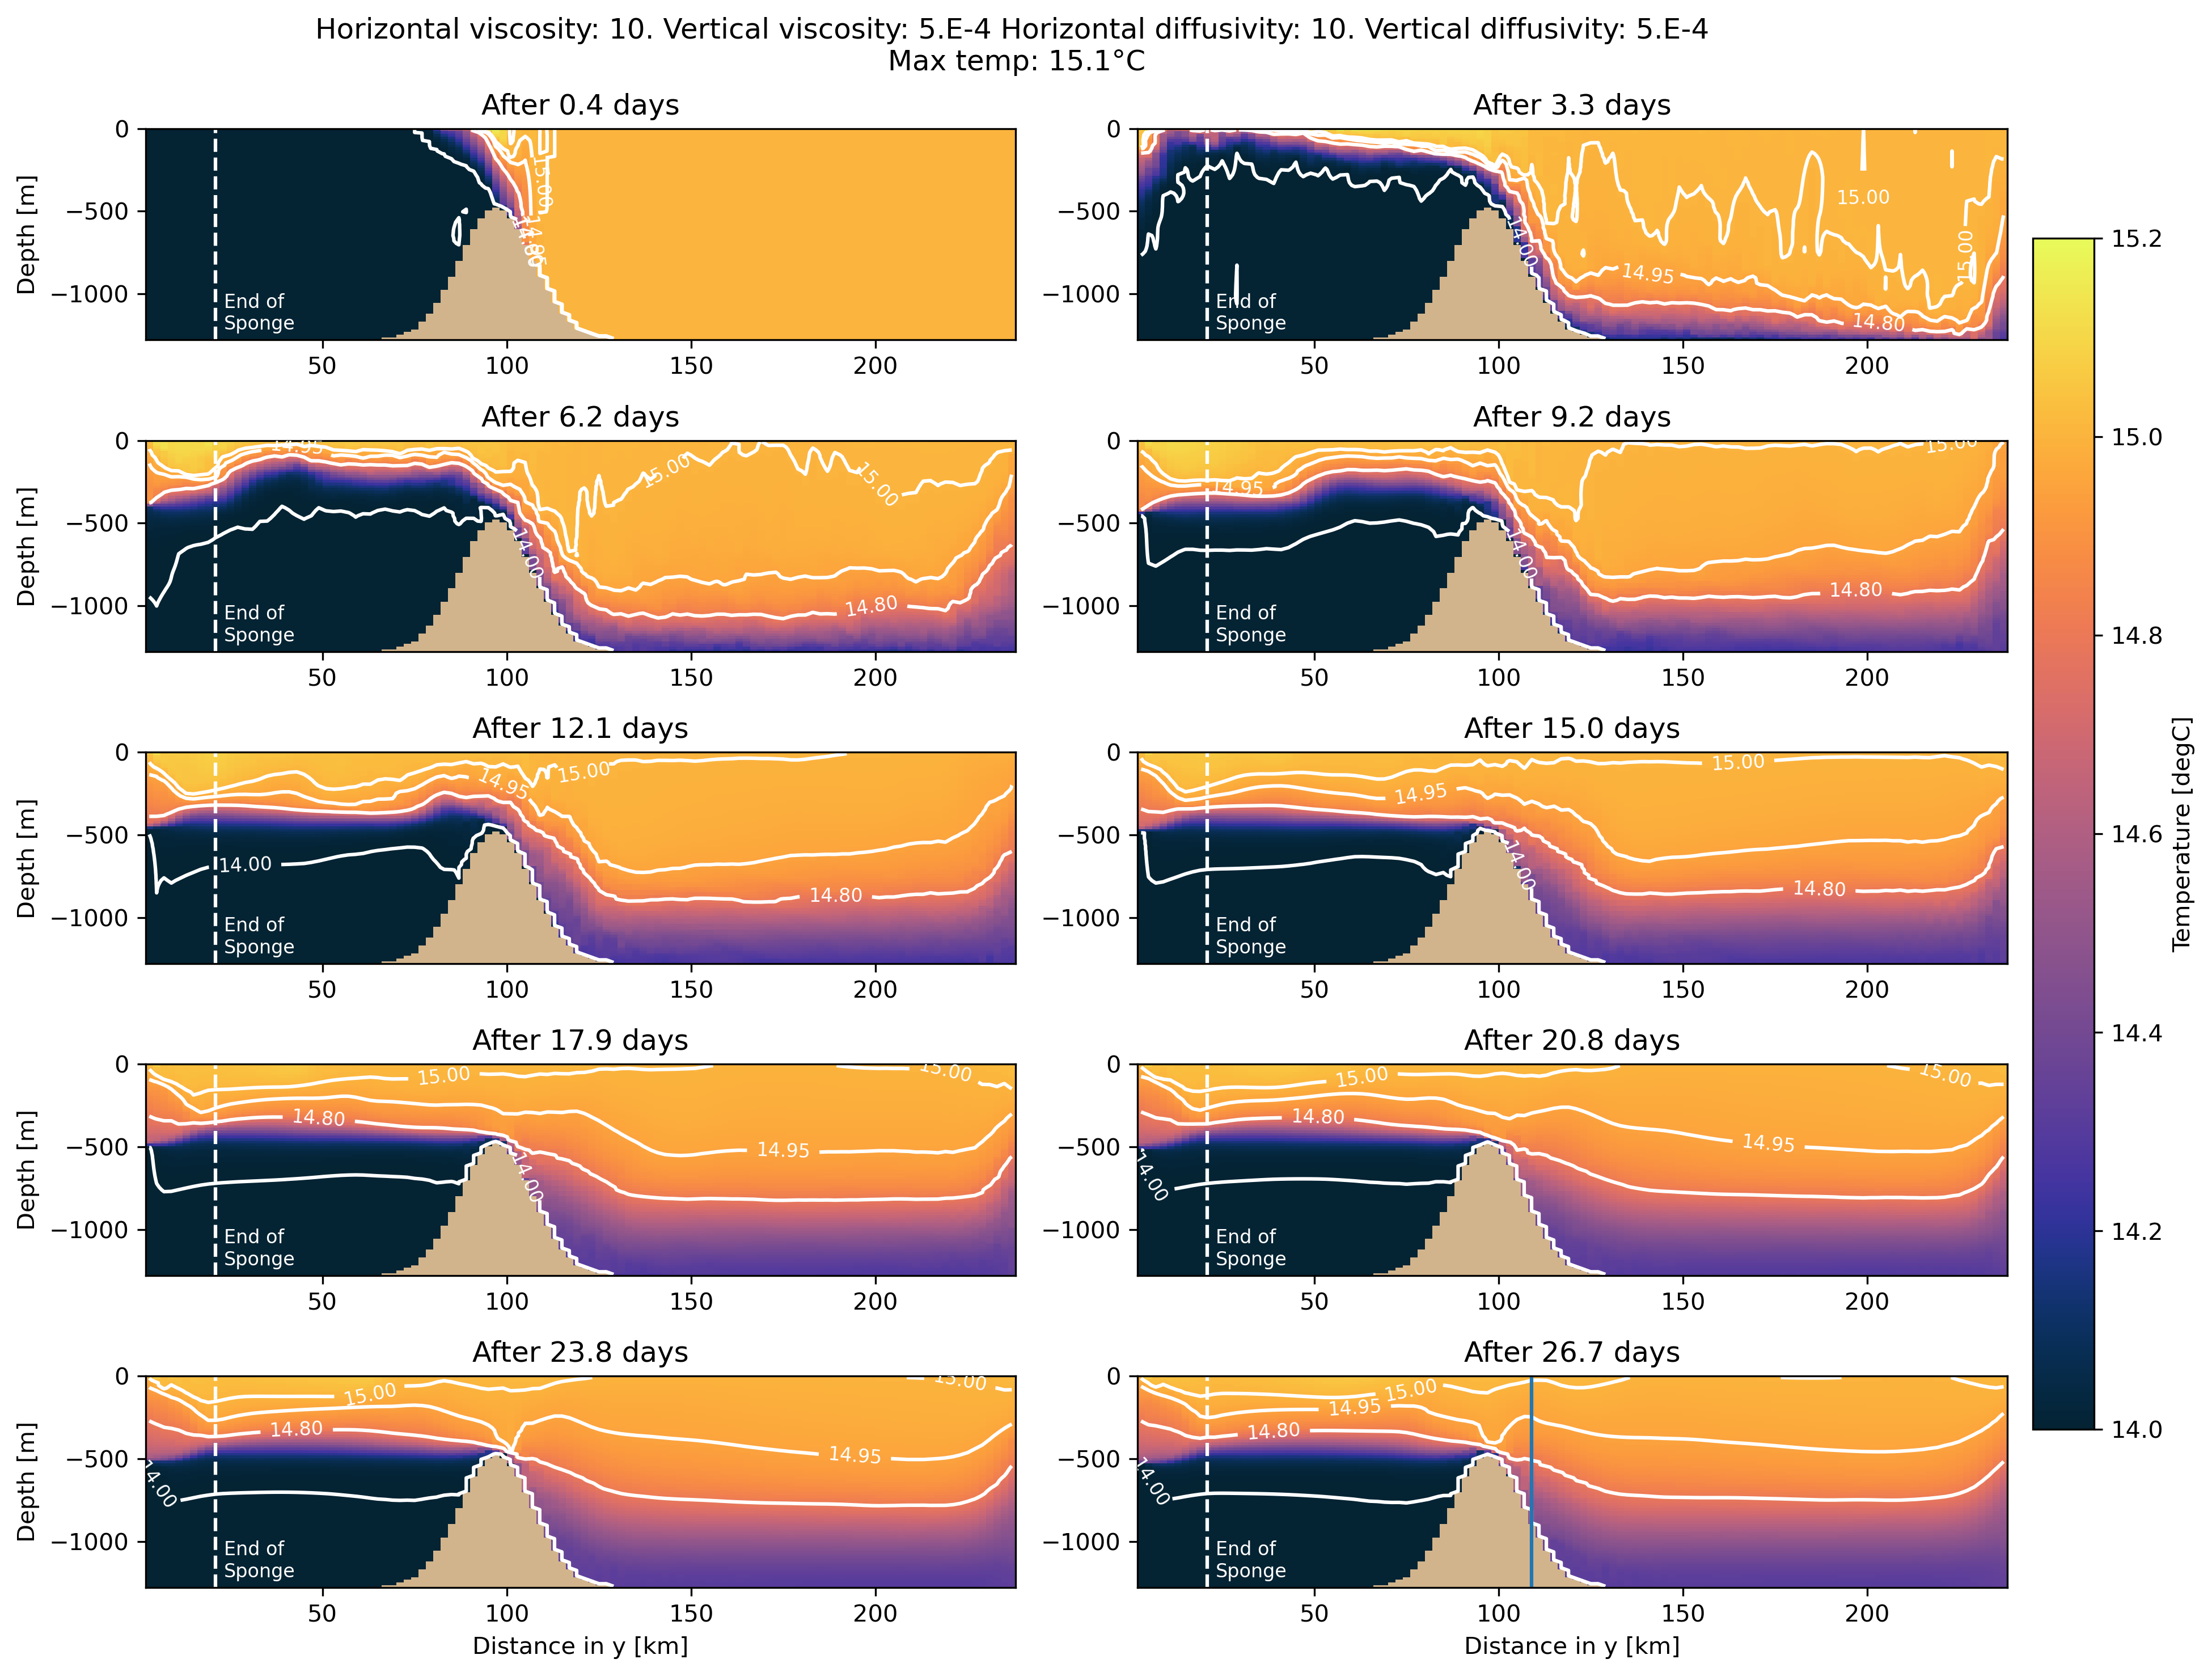

In [190]:
fig,ax = plt.subplots(5,2)

indX=5

divT=(60*60*24)
unit= 'days'
#Dambreak
tsteps=np.arange(0,66,7)
levels=np.arange(14,15.2,0.2)

#Heat of surface
#tsteps=[0,1,2,3,4,6,8,10,11,12]

### Temperature ###
vmin=14
vmax=15.2

T=ds.THETA[:,:,:,indX]
Yin=dsG.Y[OBp:OBendp]
Zin=dsG.Z

cmapi=cmocean.cm.thermal
maskin=mask[:,OBp:OBendp,indX]
levels=[14,14.8,14.95,15,16.5,18]
clab='Temperature [degC]'

### Velocity ###
#maskin=mask[:,OBp:OBendp,indX]

#T=np.mean(ds.WVEL[:,:,:,OBx:OBendx],axis=3)*100
#Yin=dsG.Y[OBp:OBendp]
#Zin=dsG.Z

#vmin=np.min(np.ma.masked_array(T[0,:,OB:OBend],mask=mask[:,OB:OBend,indX]))
#vmax=-np.min(np.ma.masked_array(T[0,:,OB:OBend],mask=mask[:,OB:OBend,indX]))
#cmapi=cmocean.cm.balance

#clab='Vertical velocity [cm/s]'

#levels=[0]


axin=ax[0,0]
tin=tsteps[0]
timein=ds.T[tin]/divT
axin.set(ylabel='Depth [m]',title=f'After {timein:.1f} ' + str(unit) )
axin.set_facecolor('tan')

cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp],mask=maskin),vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(Yin/1000, Zin, T[tin,:,OBp:OBendp],levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

axin.axvline(ds.Y[10]/1000,c='white',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

axin=ax[0,1]

tin=tsteps[1]
timein=ds.T[tin]/divT
axin.set(title=f'After {timein:.1f} ' + str(unit) )
axin.set_facecolor('tan')
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp],mask=maskin),vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(Yin/1000, Zin, T[tin,:,OBp:OBendp],levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

axin.axvline(ds.Y[10]/1000,c='white',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

axin=ax[1,0]

tin=tsteps[2]
timein=ds.T[tin]/divT
axin.set(title=f'After {timein:.1f} ' + str(unit),ylabel='Depth [m]')
axin.set_facecolor('tan')
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp],mask=maskin),vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(Yin/1000, Zin, T[tin,:,OBp:OBendp],levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

axin.axvline(ds.Y[10]/1000,c='white',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

axin=ax[1,1]

tin=tsteps[3]
timein=ds.T[tin]/divT
axin.set(title=f'After {timein:.1f} ' + str(unit) )
axin.set_facecolor('tan')
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp],mask=maskin),vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(Yin/1000, Zin, T[tin,:,OBp:OBendp],levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

axin.axvline(ds.Y[10]/1000,c='white',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

axin=ax[2,0]

tin=tsteps[4]
timein=ds.T[tin]/divT
axin.set(title=f'After {timein:.1f} ' + str(unit),ylabel='Depth [m]')
axin.set_facecolor('tan')
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp],mask=maskin),vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(Yin/1000, Zin, T[tin,:,OBp:OBendp],levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)
axin.axvline(ds.Y[10]/1000,c='white',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

axin=ax[2,1]

tin=tsteps[5]
timein=ds.T[tin]/divT
axin.set(title=f'After {timein:.1f} ' + str(unit) )

axin.set_facecolor('tan')

cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp],mask=maskin),vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(Yin/1000, Zin, T[tin,:,OBp:OBendp],levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

axin.axvline(ds.Y[10]/1000,c='white',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

axin=ax[3,0]

tin=tsteps[6]
timein=ds.T[tin]/divT
axin.set(title=f'After {timein:.1f} ' + str(unit),ylabel='Depth [m]')

axin.set_facecolor('tan')

cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp],mask=maskin),vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(Yin/1000, Zin, T[tin,:,OBp:OBendp],levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

axin.axvline(ds.Y[10]/1000,c='white',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

axin=ax[3,1]

tin=tsteps[7]
timein=ds.T[tin]/divT
axin.set(title=f'After {timein:.1f} ' + str(unit) )

axin.set_facecolor('tan')

cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp],mask=maskin),vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(Yin/1000, Zin, T[tin,:,OBp:OBendp],levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

axin.axvline(ds.Y[10]/1000,c='white',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

axin=ax[4,0]

tin=tsteps[8]
timein=ds.T[tin]/divT
axin.set(title=f'After {timein:.1f} ' + str(unit),ylabel='Depth [m]',xlabel='Distance in y [km]')

axin.set_facecolor('tan')

cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp],mask=maskin),vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(Yin/1000, Zin, T[tin,:,OBp:OBendp],levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

axin.axvline(ds.Y[10]/1000,c='white',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

axin=ax[4,1]

tin=tsteps[9]
timein=ds.T[tin]/divT
axin.set(title=f'After {timein:.1f} ' + str(unit),xlabel='Distance in y [km]' )

axin.set_facecolor('tan')

cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp],mask=maskin),vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(Yin/1000, Zin, T[tin,:,OBp:OBendp],levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

axin.axvline(ds.Y[10]/1000,c='white',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)


fig.suptitle(f'{plotNames[0]}: {plotValues[0]} {plotNames[1]}: {plotValues[1]} {plotNames[2]}: {plotValues[2]} {plotNames[3]}: {plotValues[3]}\n Max temp: {np.max(np.ma.masked_array(ds.THETA[tin,:,OB:OBend,OBx+1:OBendx-1],mask=mask[:,OB:OBend,OBx+1:OBendx-1])):.1f}°C')

cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7])
fig.colorbar(cax0, cax=cbar_ax)
cbar_ax.set_ylabel(clab)

axin.axvline(ds.Y[int(len(dsG.Y)*0.45)]/1000)

fig.tight_layout()



In [191]:
params = {'font.size': 18,
          'figure.figsize': (12, 10),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

/var/folders/gd/3bct0xc153g57jtc04sdbb240000gn/T/ipykernel_3445/2636796451.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


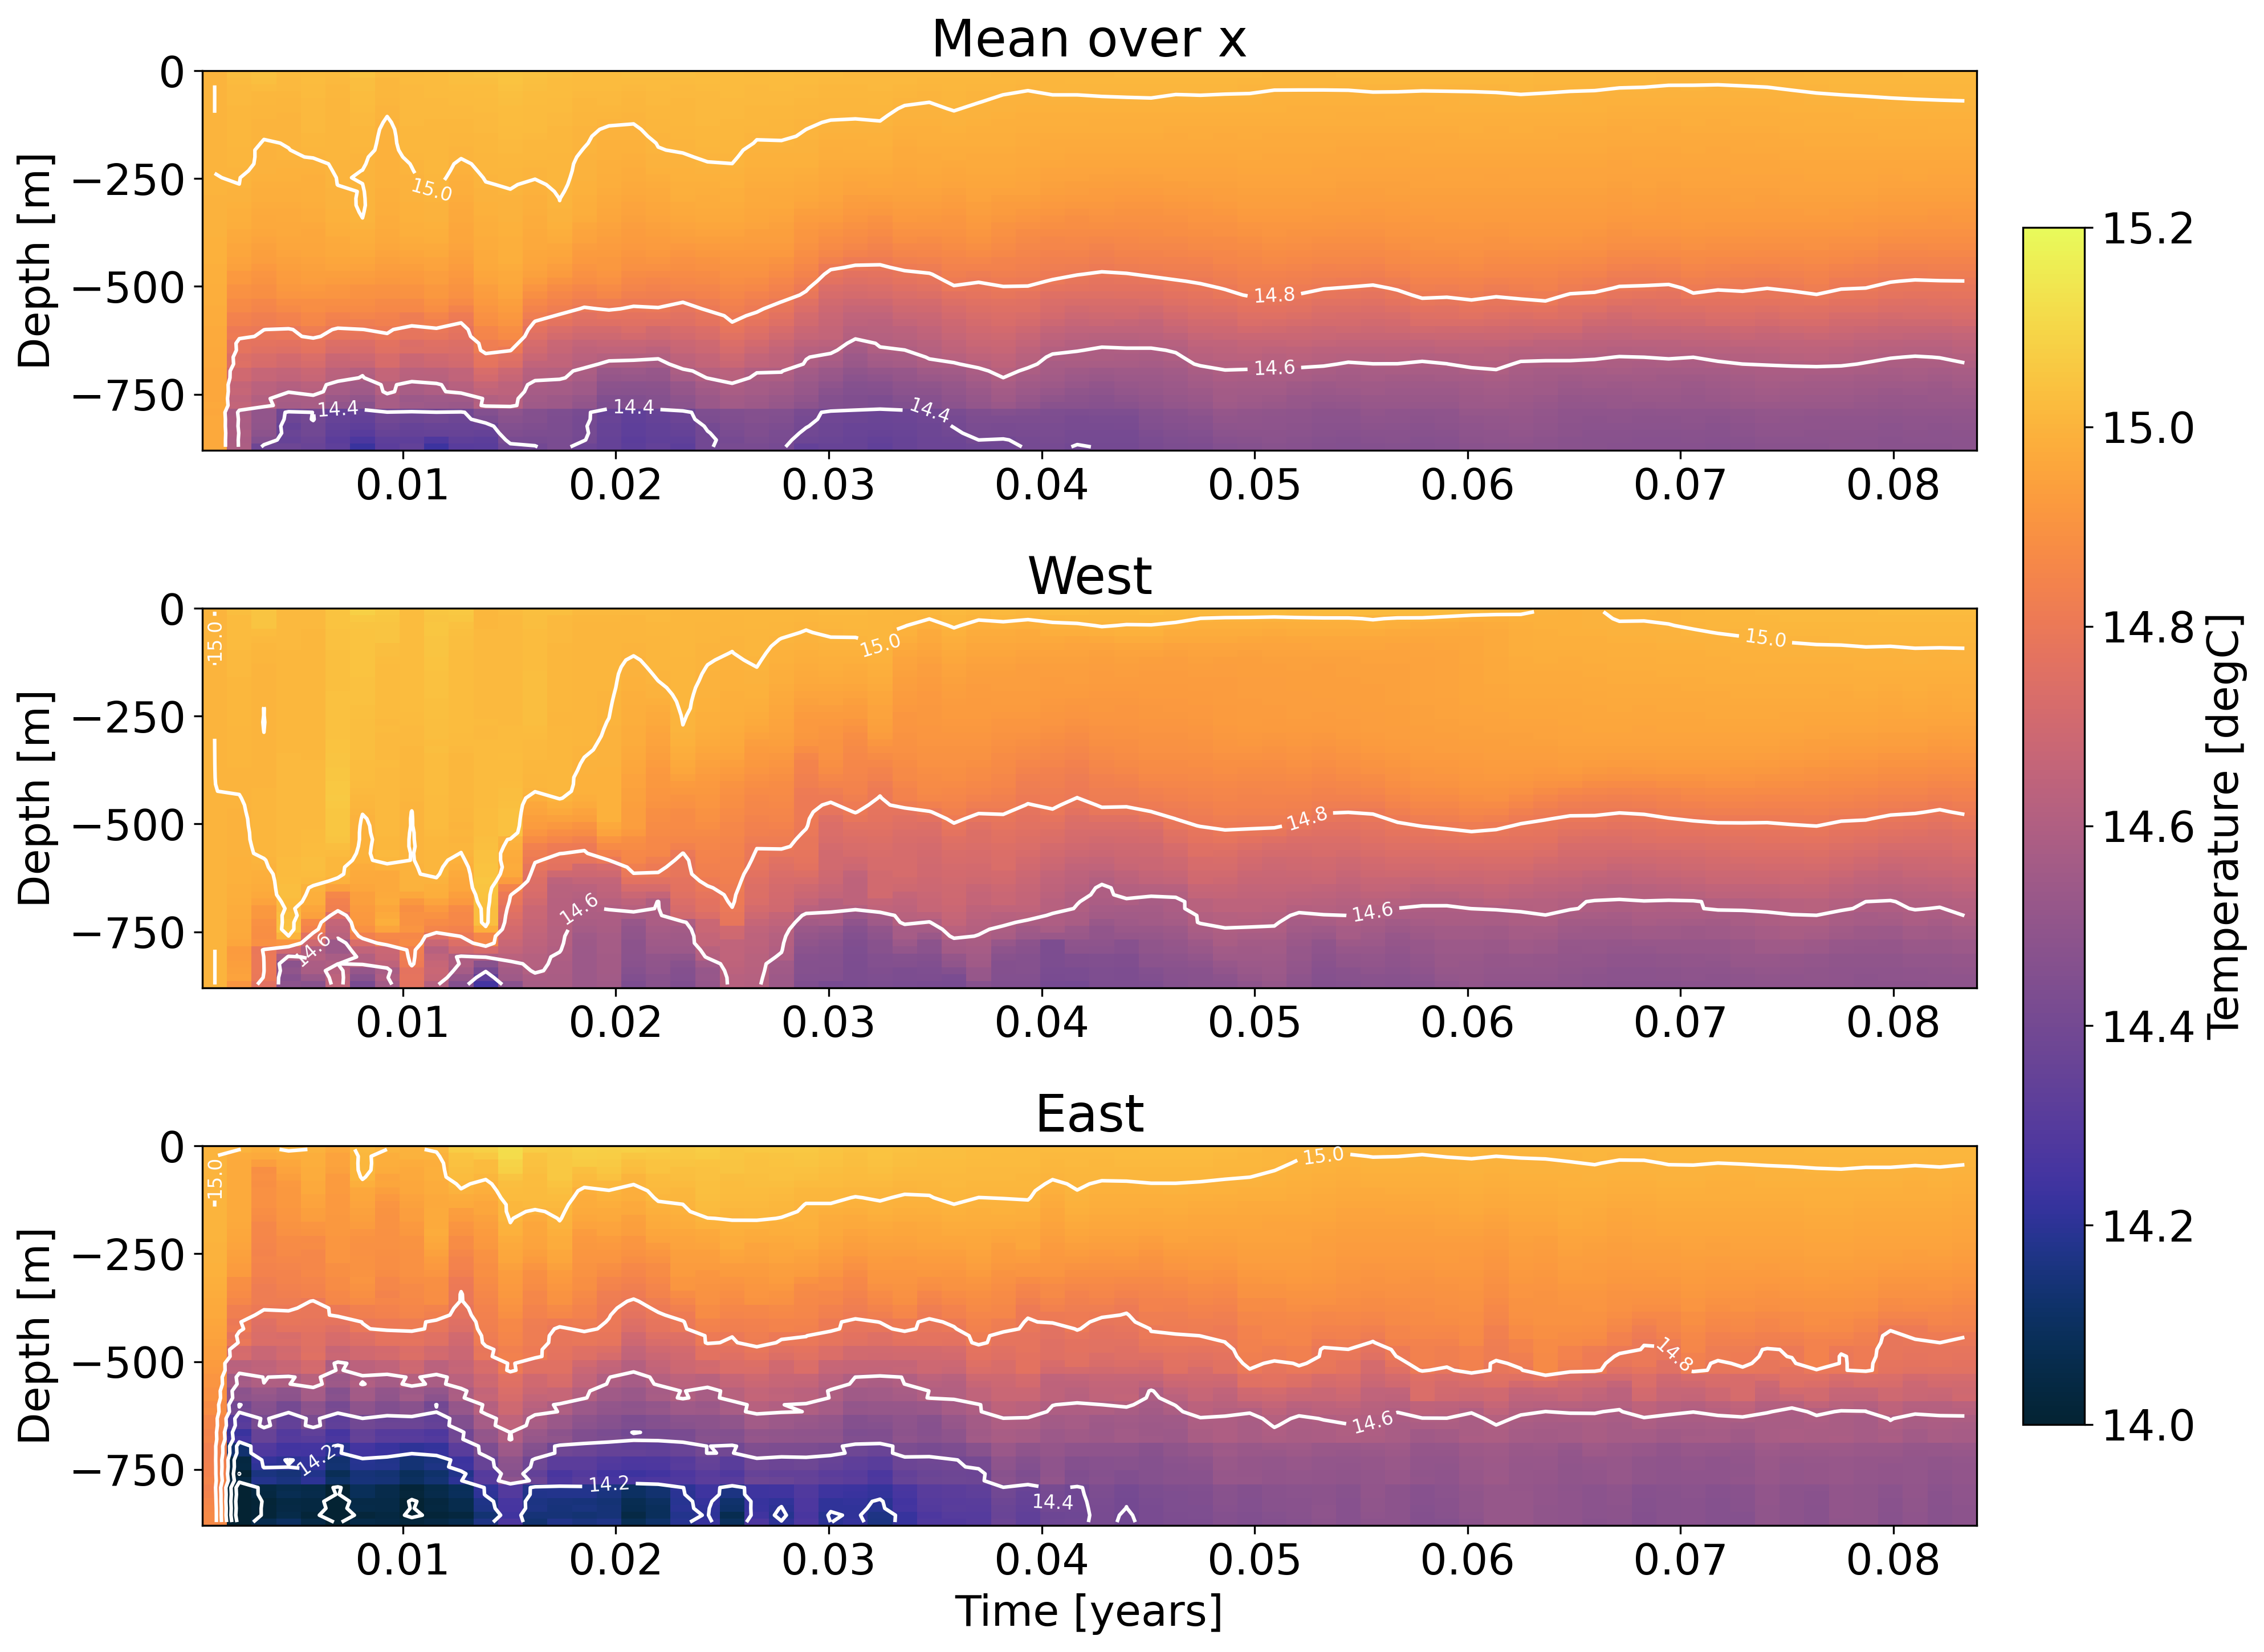

In [193]:
fig,ax = plt.subplots(3)


umb=int(len(dsG.Y)*0.45)
bottom=np.where(ds.THETA[tin,:,umb,5].values!=0)[0][-1]


### Temperature ### 
vmin=14
vmax=15.2
levels=np.arange(vmin,vmax,step)

cmapi=cmocean.cm.thermal

val=ds.THETA
#vmin=15
#vmax=18
#levels=[14,14.8,14.95,15,16.5,18]
clab='Temperature [degC]'


### Velocity ###

#val=ds.VVEL*100

#vmin=np.min(val[:,:bottom,umb,OBx:OBendx])
#vmax=-np.min(val[:,:bottom,umb,OBx:OBendx])
#cmapi=cmocean.cm.balance

#levels=[0]
#clab='Meridional velocity [cm/s]'


Zin=dsG.Z[:bottom]
timein=ds.T/(60*60*24*360)




axin=ax[0]
T=np.mean(val[:,:bottom,umb,OBx:OBendx],axis=2)
axin.set(ylabel='Depth [m]',title=f'Mean over x' )
axin.set_facecolor('tan')

cax0=axin.pcolormesh(timein, Zin, T.T,vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(timein, Zin, T.T,levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

axin=ax[1]
indX=OBx
T=val[:,:bottom,umb,indX]
axin.set(ylabel='Depth [m]',title=f'West' )
axin.set_facecolor('tan')

cax0=axin.pcolormesh(timein, Zin, T.T,vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(timein, Zin, T.T,levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)

axin=ax[2]
indX=OBendx-1
T=val[:,:bottom,umb,indX]
axin.set(ylabel='Depth [m]',xlabel='Time [years]',title=f'East' )
axin.set_facecolor('tan')

cax0=axin.pcolormesh(timein, Zin, T.T,vmin=vmin,vmax=vmax,cmap=cmapi)
caxC=axin.contour(timein, Zin, T.T,levels=levels,colors='white')
axin.clabel(caxC, inline=1, fontsize=8)
cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7])
fig.colorbar(cax0, cax=cbar_ax)
cbar_ax.set_ylabel(clab)


fig.tight_layout()

Text(0.5, 1.05, 'After 6.5 years\n Horizontal viscosity: 10. Vertical viscosity: 5.E-4 Horizontal diffusivity: 10. Vertical diffusivity: 5.E-4')

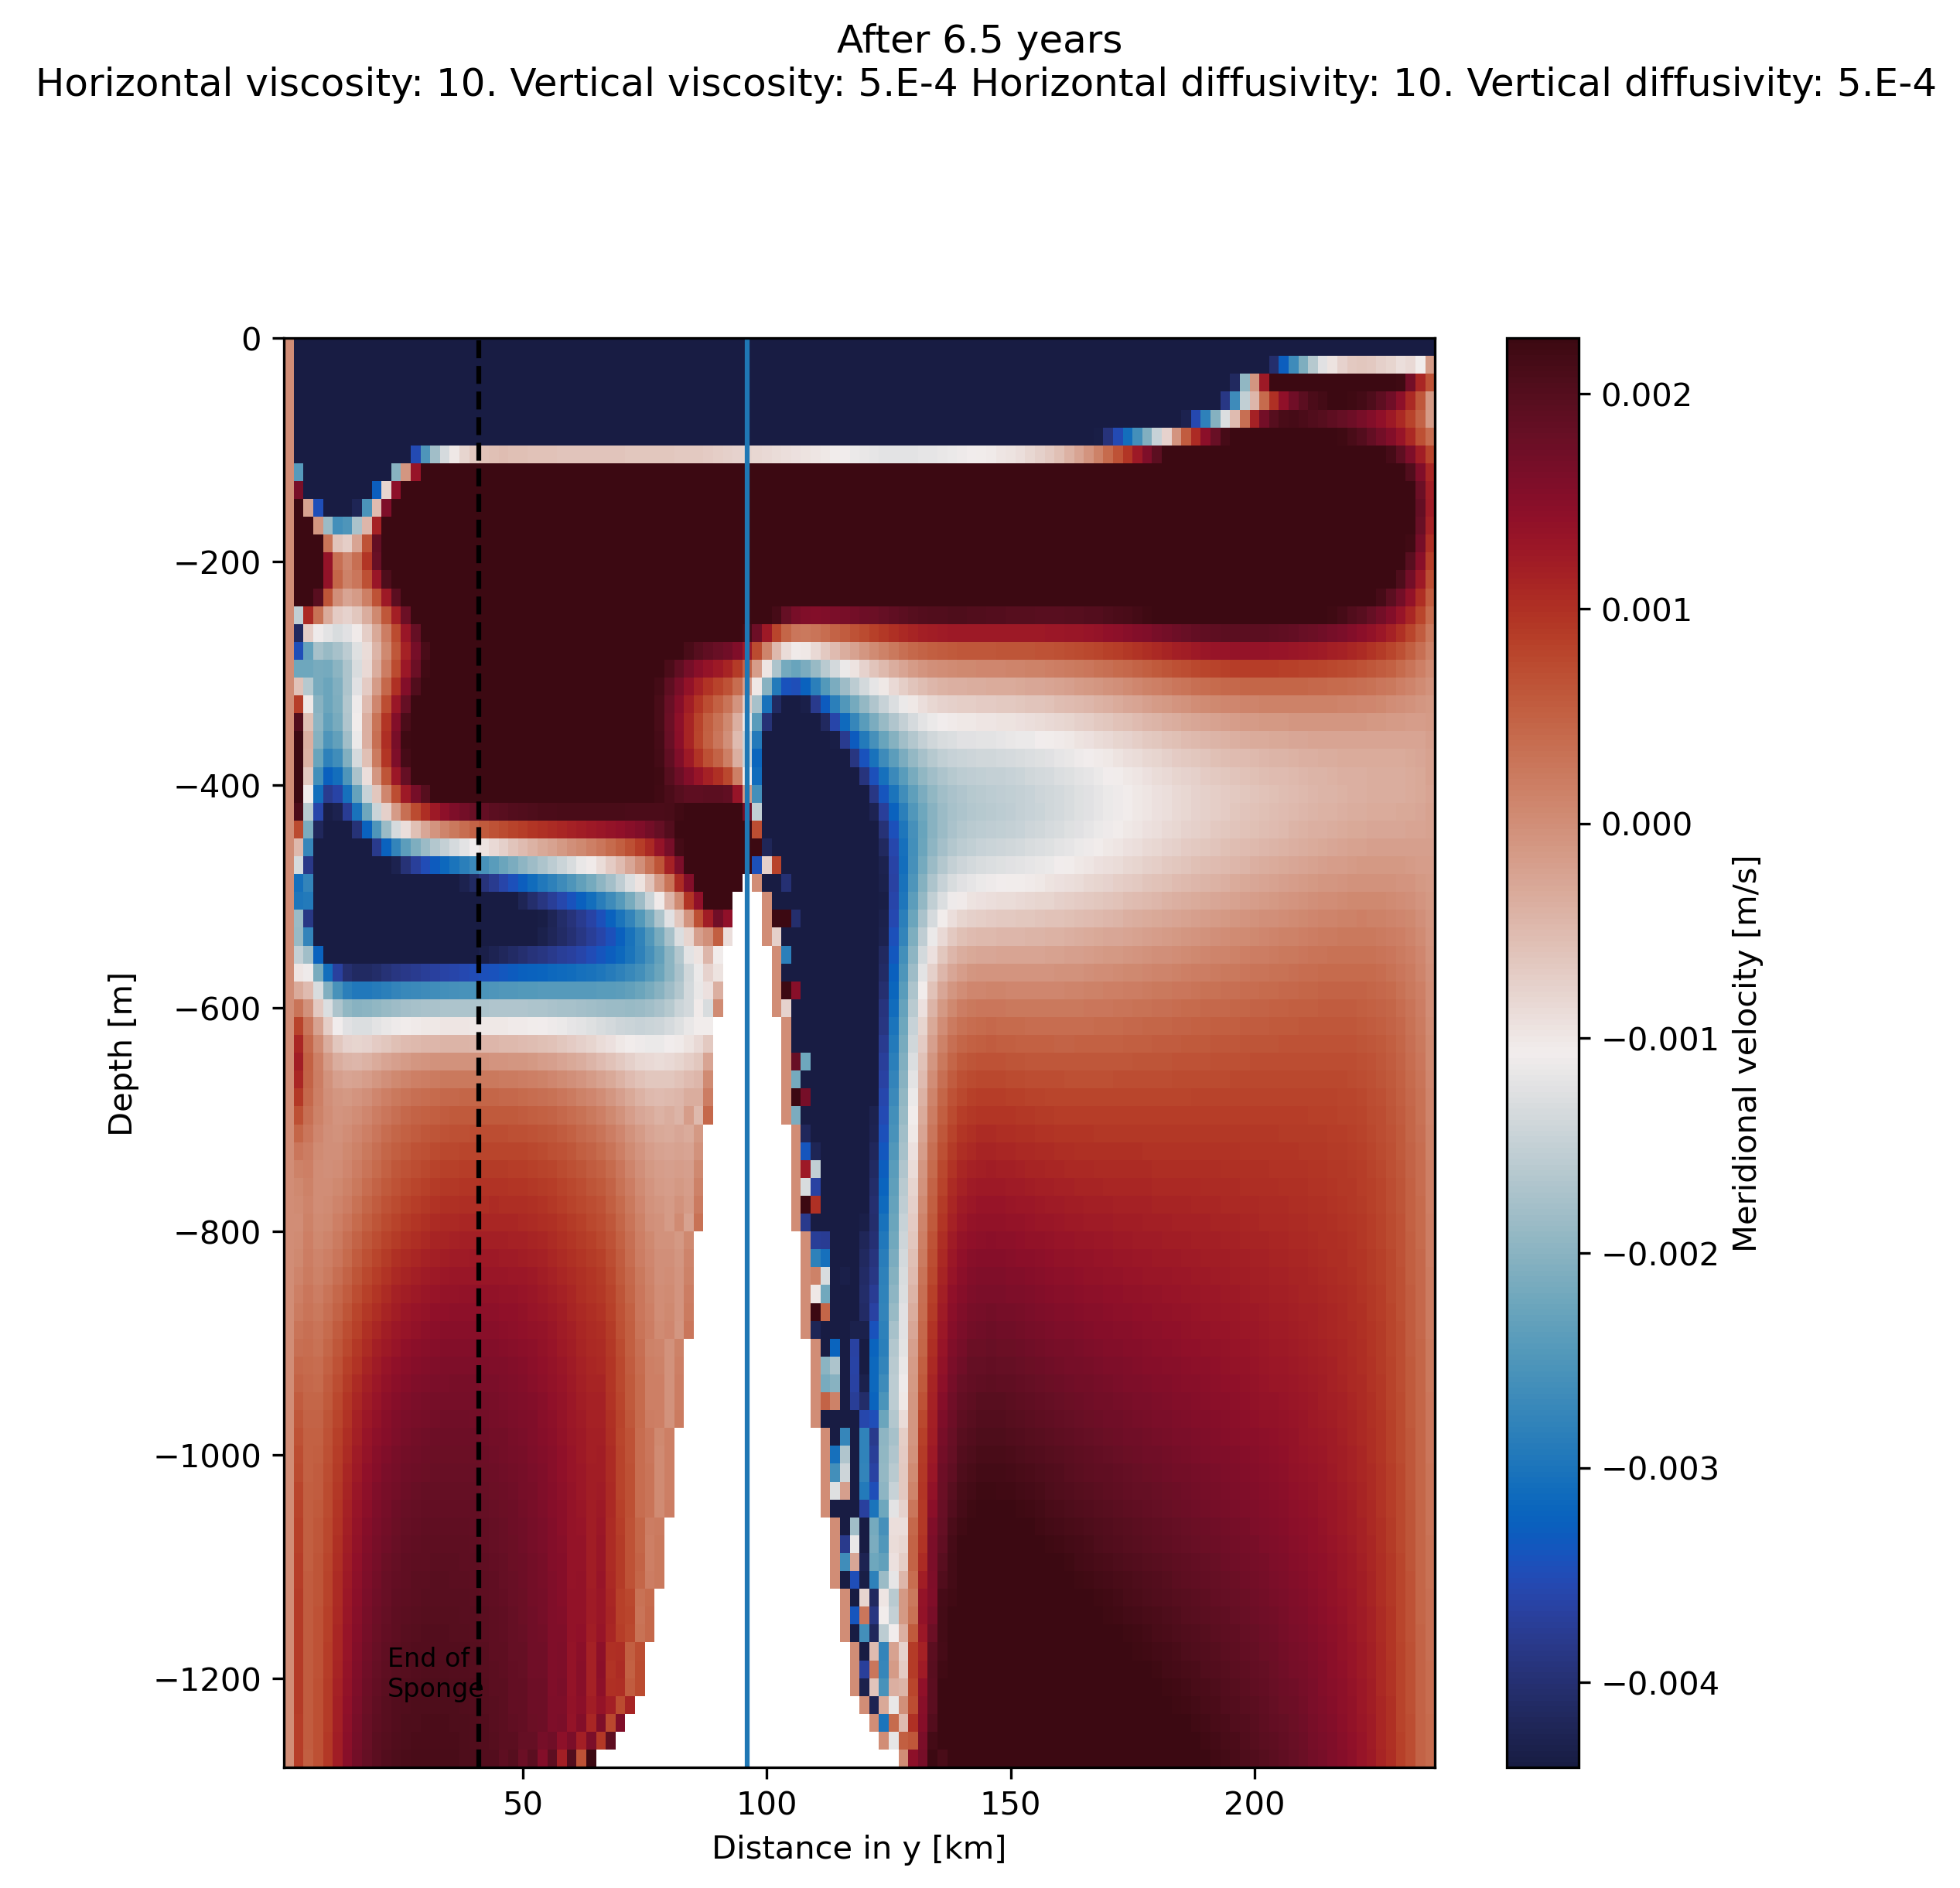

In [21]:
fig,axin = plt.subplots()
axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

V=ds.VVEL[:,:,:-1,:]
Yin=dsG.Yp1[OBp:OBendp-1]
Zin=dsG.Z


vmin=np.min(np.ma.masked_array(V[tin,:,OB:OBend,5],mask=mask[:,OB:OBend,5]))/10
vmax=np.max(np.ma.masked_array(V[tin,:,OB:OBend,5],mask=mask[:,OB:OBend,5]))/10
cmapi=cmocean.cm.balance


timein=ds.T[-1]/(60*60*24*360)
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(V[-1,:,OBp:OBendp,5],mask=mask[:,OBp:OBendp,5]),vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, np.ma.masked_array(V[-1,:,OBp:OBendp,0]),levels=0)#[15,15.5,16,16.2,16.5,16.8,17.2,18,20])
#plt.clabel(caxC, inline=1, fontsize=8)
axin.axvline(ds.Y[20]/1000,c='k',linestyle='dashed')

axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)
cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Meridional velocity [m/s]')
fig.suptitle(f'After {timein:.1f} years\n {plotNames[0]}: {plotValues[0]} {plotNames[1]}: {plotValues[1]} {plotNames[2]}: {plotValues[2]} {plotNames[3]}: {plotValues[3]}',y=1.05)


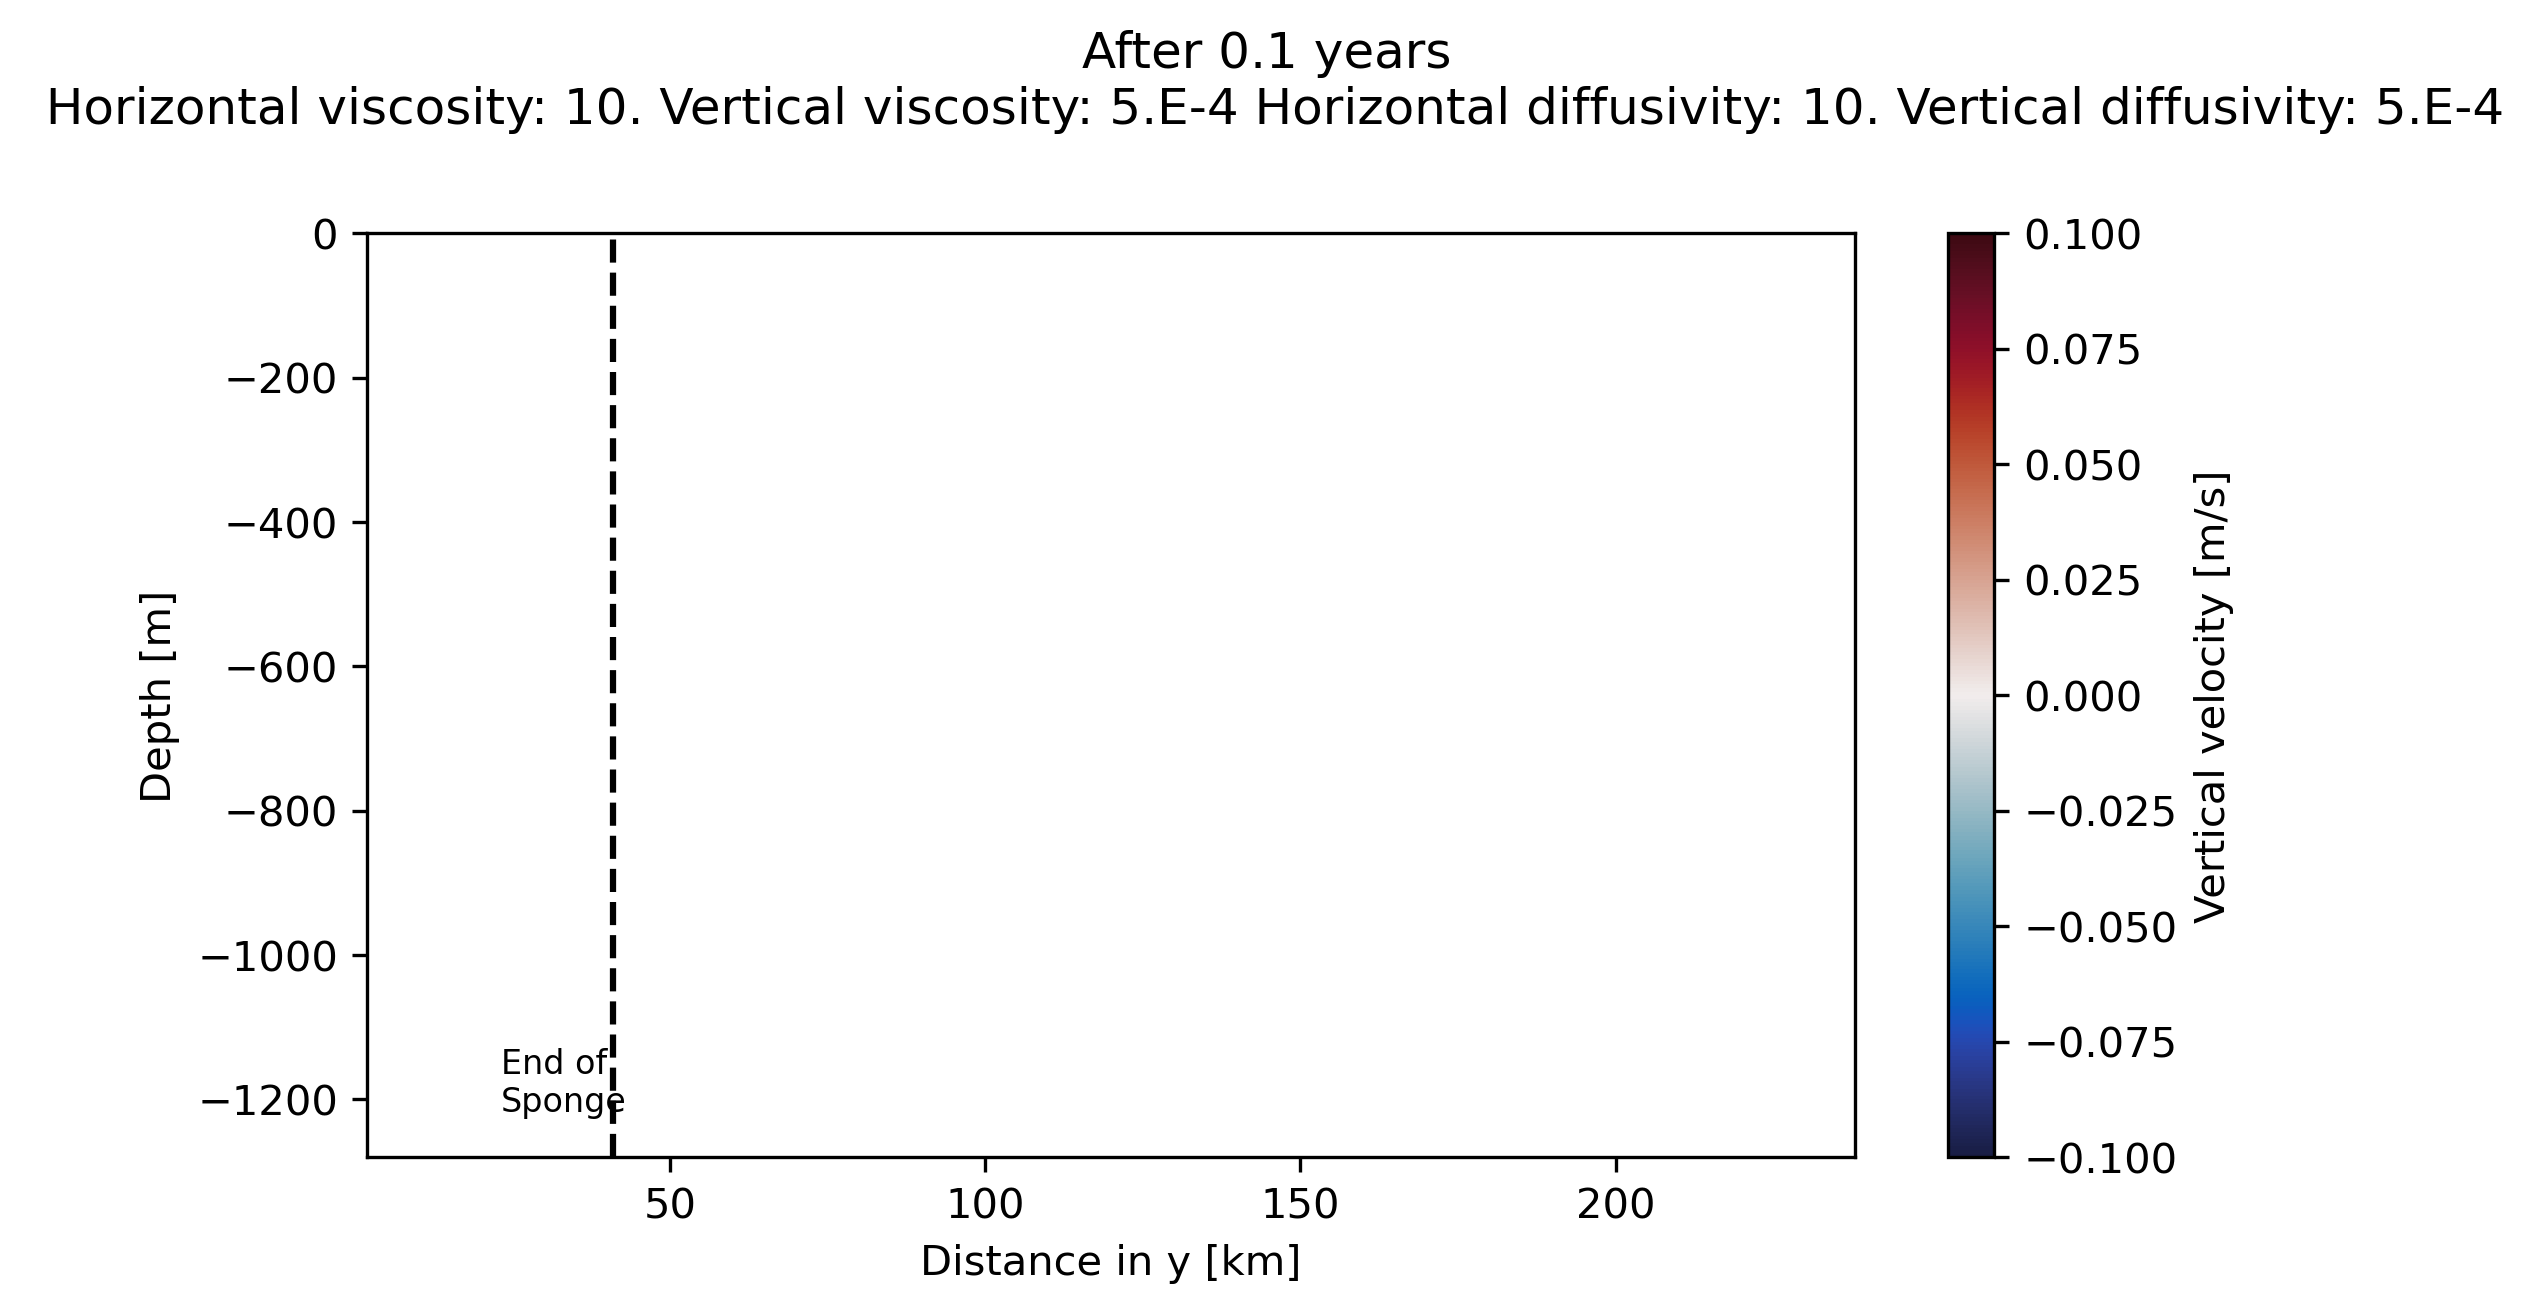

In [67]:
fig,axin = plt.subplots()
axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

W=ds.WVEL
Yin=dsG.Y[OBp:OBendp]
Zin=dsG.Z

vmin=np.min(np.ma.masked_array(W[tin,:,OB:OBend,0],mask=mask[:,OB:OBend,0]))
vmax=np.max(np.ma.masked_array(W[tin,:,OB:OBend,0],mask=mask[:,OB:OBend,0]))
cmapi=cmocean.cm.balance


timein=ds.T[-1]/(60*60*24*360)
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(W[-1,:,OBp:OBendp,0],mask=mask[:,OBp:OBendp,0]),vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, np.ma.masked_array(W[-1,:,OBp:OBendp,0]),levels=0)#[15,15.5,16,16.2,16.5,16.8,17.2,18,20])
fig.suptitle(f'After {timein:.1f} years\n {plotNames[0]}: {plotValues[0]} {plotNames[1]}: {plotValues[1]} {plotNames[2]}: {plotValues[2]} {plotNames[3]}: {plotValues[3]}',y=1.05)

axin.axvline(ds.Y[20]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Vertical velocity [m/s]')

In [43]:
def animate(t):
    tt=((ds.T.values[t])/(60*60*24))
    cax0.set_array(np.ma.masked_array(T[t,:,OBp:OBendp,5],mask=mask[:,OBp:OBendp,5]))
    cax1.set_array(np.ma.masked_array(V[t,:,OBp:OBendp,5]*100,mask=masks[:,OBp:OBendp,5]))
    cax2.set_array(np.ma.masked_array(U[t,:,OBp:OBendp,5]*100,mask=maskw[:,OBp:OBendp,5]))
    cax3.set_array(np.ma.masked_array(W[t,:,OBp:OBendp,5]*100,mask=mask[:,OBp:OBendp,5]))
    fig.suptitle(f'After {tt:.1f} days')



In [44]:
Writer = animation.writers['ffmpeg']
writer = Writer(fps=4, metadata=dict(artist='AM'), bitrate=2000)

In [45]:
tin=0
divV=1
divU=1
divW=1

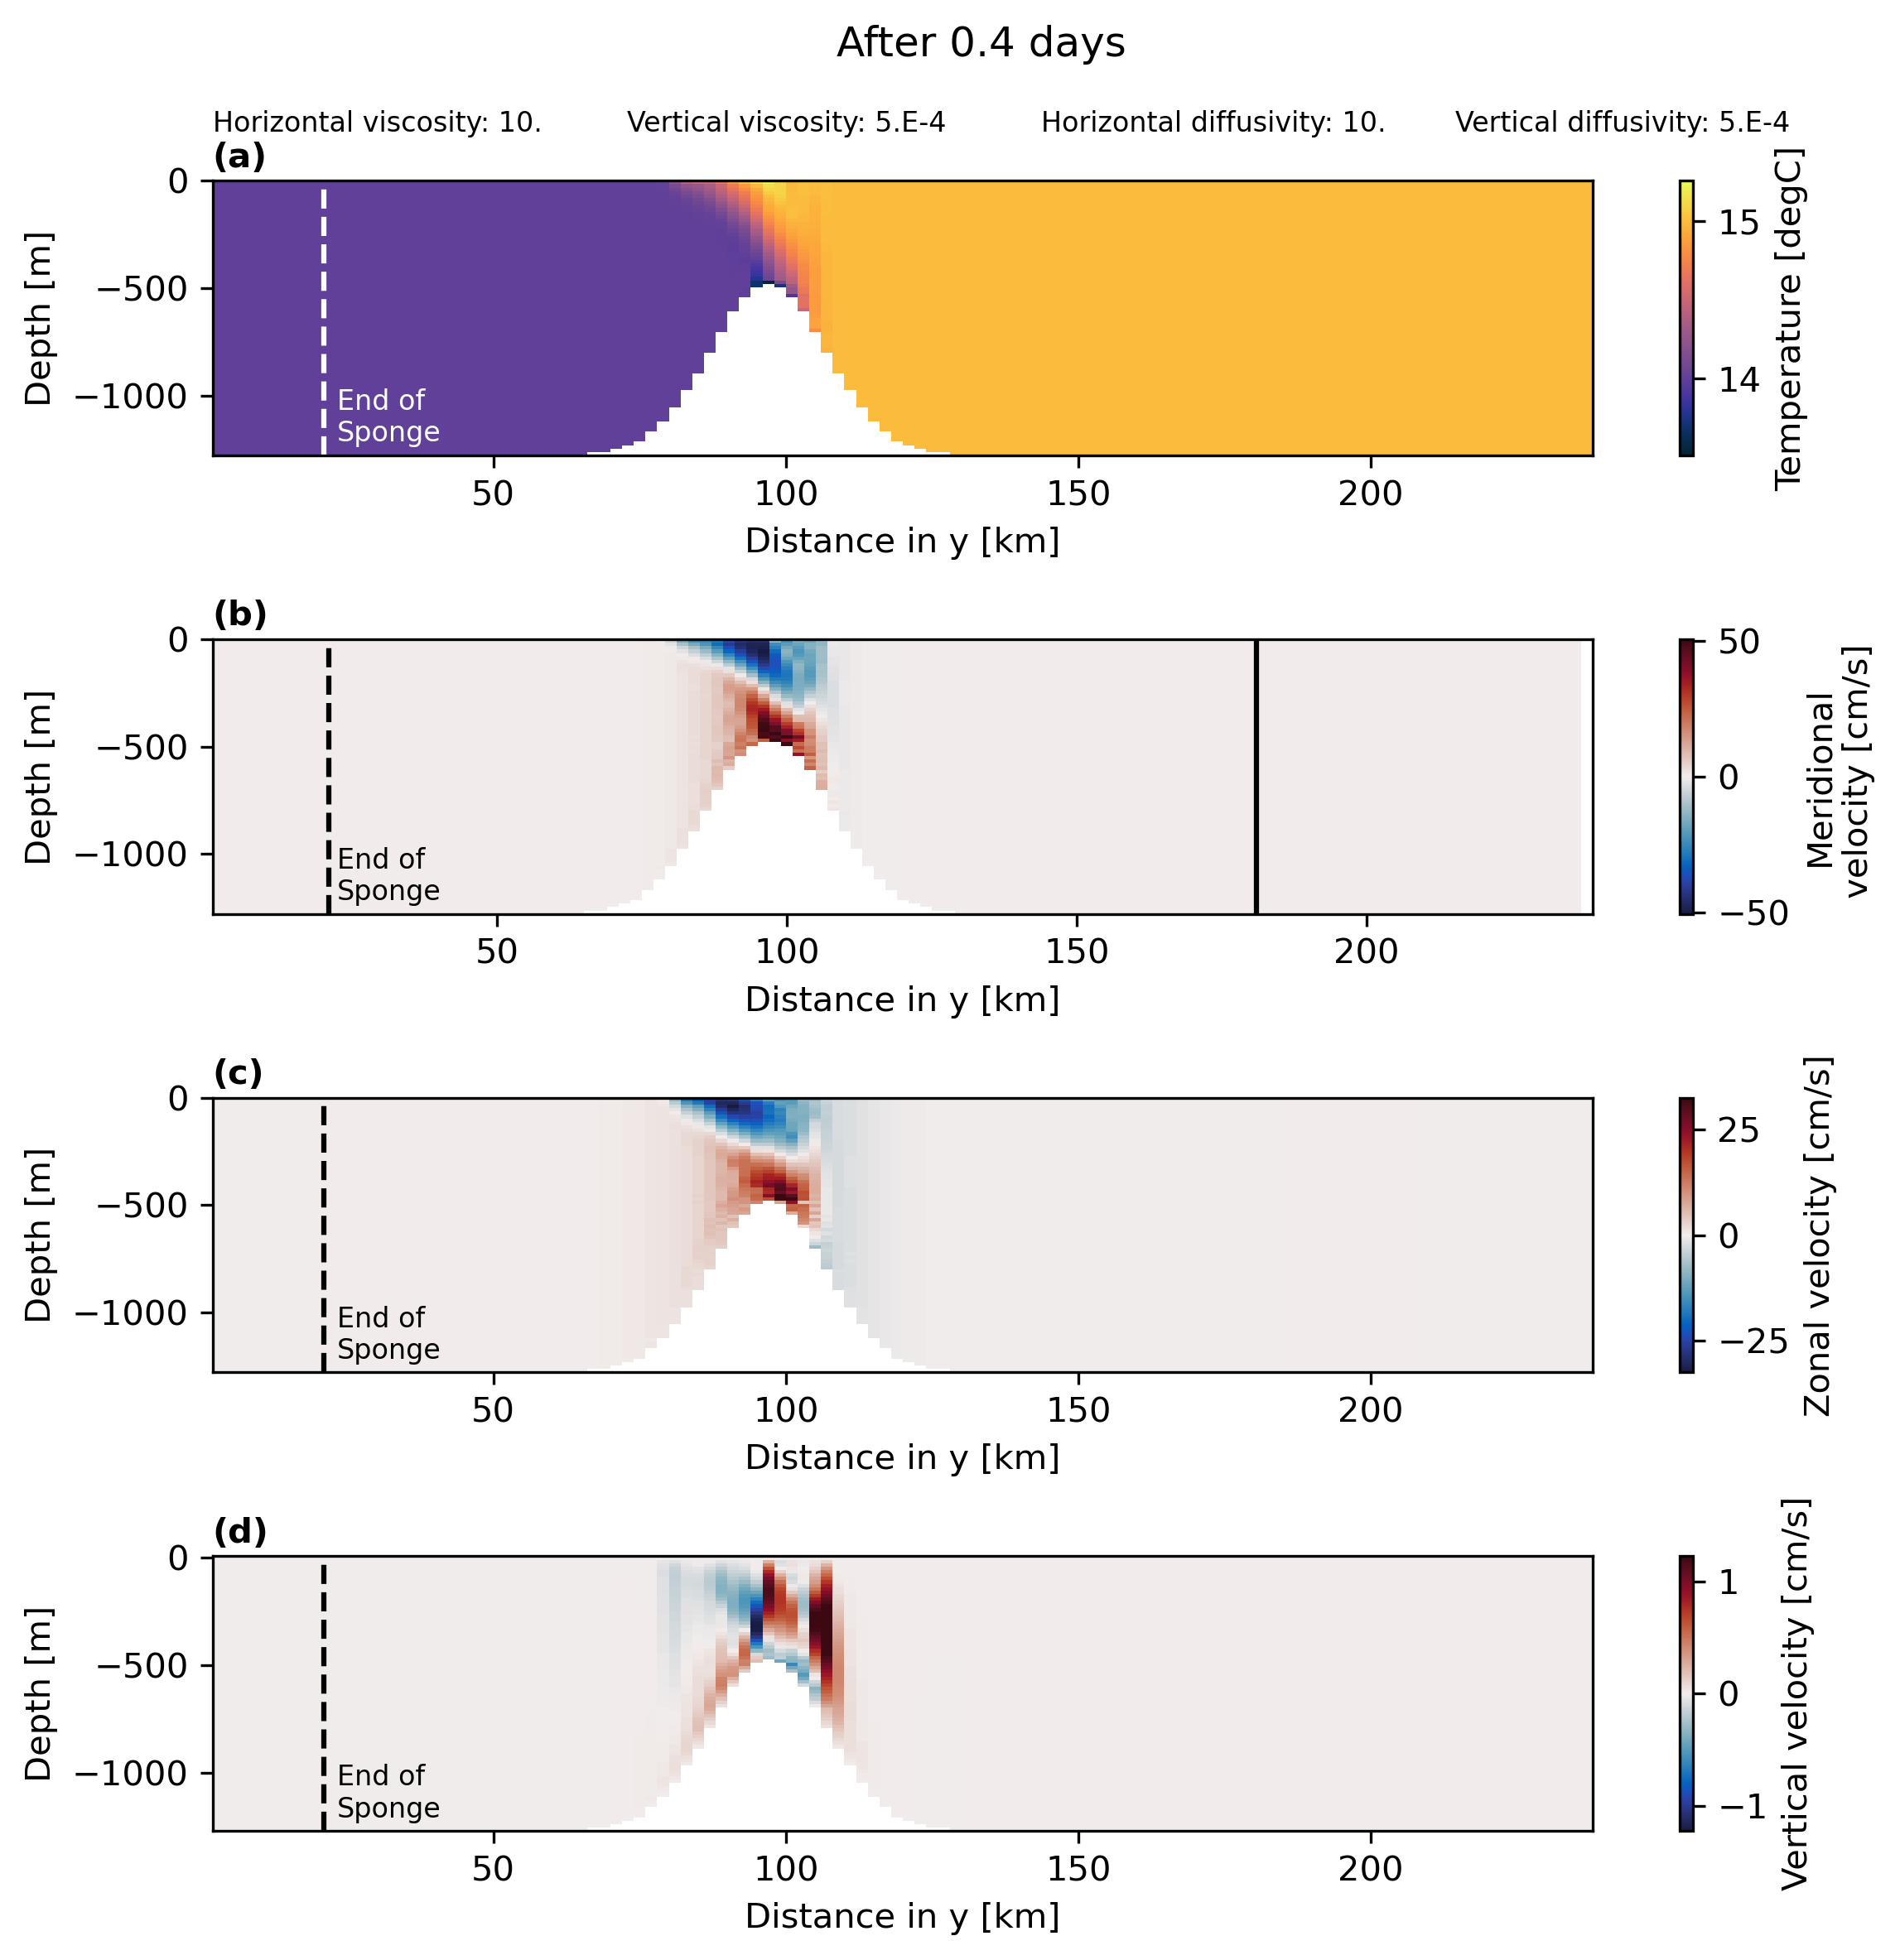

In [46]:
params = {'font.size': 10,
          'figure.figsize': (8, 8),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
tin=0
fig = plt.figure()
gs = GridSpec(nrows=4, ncols=1)
axin = fig.add_subplot(gs[0, 0])
axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

T=ds.THETA
Yin=dsG.Y[OBp:OBendp]
Zin=dsG.Z

vmin=np.min(np.ma.masked_array(T[tin,:,OB:OBend,5],mask=mask[:,OB:OBend,5]))
vmax=np.max(np.ma.masked_array(T[tin,:,OB:OBend,5],mask=mask[:,OB:OBend,5]))
cmapi=cmocean.cm.thermal


timein=ds.T[tin]/(60*60*24*360)
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp,5],mask=mask[:,OBp:OBendp,5]),vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp,5]),levels=[15,15.02,15.08,15.2,15.5],colors='cyan')
#plt.clabel(caxC, inline=1, fontsize=8)
cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Temperature [degC]')

axin.text(0, 1.05, '(a)', fontweight='bold', color='k', 
        transform=axin.transAxes)

axin.axvline(ds.Y[OB]/1000,c='white',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

s=1.18
for i in range(len(plotNames)):
    if i>3:
        s=1.15
        i=i-2
    axin.text(0+i*0.3, s, f'{plotNames[i]}: {plotValues[i]}', color='black', 
            transform=axin.transAxes,fontsize=8)

    
#axin.set_title(f'{plotNames[0]}:{plotValues[0]}, {plotNames[1]}:{plotValues[1]}\n {plotNames[2]}:{plotValues[2]}, {plotNames[3]}:{plotValues[3]}',fontsize=10)


axin = fig.add_subplot(gs[1, 0])

V=ds.VVEL.values

title= ds.VVEL.description 
Yin=ds.Yp1[OBp:OBendp]

vmin=np.min(np.ma.masked_array(V[tin,:,OB:OBend,5]*100,mask=masks[:,OB:OBend,5]))/divV
vmax=-np.min(np.ma.masked_array(V[tin,:,OB:OBend,5]*100,mask=masks[:,OB:OBend,5]))/divV
cmapi=cmocean.cm.balance


axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

timein=ds.T[-tin]/(60*60*24)
cax1=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(V[tin,:,OBp:OBendp,5]*100,mask=masks[:,OBp:OBendp,5]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax1)
axin.axvline(ds.Y[int(0.75*ny)]/1000,c='k')
cbar_ax.set_label('Meridional\n velocity [cm/s]')




axin.text(0, 1.05, '(b)', fontweight='bold', color='k', 
        transform=axin.transAxes)

axin.axvline(ds.Y[OB]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

axin = fig.add_subplot(gs[2, 0])

U=ds.UVEL
title= U.description 
Yin=ds.Y[OBp:OBendp]

vmin=np.min(np.ma.masked_array(U[tin,:,OB:OBend,5],mask=maskw[:,OB:OBend,5])*100)/divU
vmax=-np.min(np.ma.masked_array(U[tin,:,OB:OBend,5],mask=maskw[:,OB:OBend,5])*100)/divU
cmapi=cmocean.cm.balance



axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

timein=ds.T[-tin]/(60*60*24)
cax2=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(U[tin,:,OBp:OBendp,5,]*100,mask=maskw[:,OBp:OBendp,5]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax2)
cbar_ax.set_label('Zonal velocity [cm/s]')


axin.text(0, 1.05, '(c)', fontweight='bold', color='k', 
        transform=axin.transAxes)

axin.axvline(ds.Y[OB]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)



W=ds.WVEL.values

title= ds.WVEL.description 
Yin=dsG.Y[OBp:OBendp]
Zin=dsG.Zl

vmin=np.min(np.ma.masked_array(W[tin,:,OB:OBend,5]*100,mask=mask[:,OB:OBend,5]))/divW
vmax=-np.min(np.ma.masked_array(W[tin,:,OB:OBend,5]*100,mask=mask[:,OB:OBend,5]))/divW
cmapi=cmocean.cm.balance

axin = fig.add_subplot(gs[3, 0])

axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

timein=ds.T[-tin]/(60*60*24)
cax3=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(W[tin,:,OBp:OBendp,5]*100,mask=mask[:,OBp:OBendp,5]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax3)
cbar_ax.set_label('Vertical velocity [cm/s]')

axin.axvline(ds.Y[OB]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

axin.text(0, 1.05, '(d)', fontweight='bold', color='k', 
        transform=axin.transAxes)
tt=0
fig.suptitle(f'After {tt:.1f} days')

fig.tight_layout()
anim = FuncAnimation(fig, animate,frames=np.arange(0,len(ds.T.values),1), repeat=False,interval=600)

anim.save('../' + str(project)+'/Figures/' +str(ed)+ 'crossects'  +'viscHor'+str(plotValues[0])+'viscVert'+str(plotValues[1])+'diffHor'+str(plotValues[2]) +'diffVert'+str(plotValues[3])+ '.mp4', writer=writer, dpi=600)


In [47]:
def animatemean(t):
    tt=((ds.T.values[t])/(60*60*24))
    cax0.set_array(np.ma.masked_array(T[t,:,OBp:OBendp],mask=mask[:,OBp:OBendp,5]))
    cax1.set_array(np.ma.masked_array(V[t,:,OBp:OBendp]*100,mask=masks[:,OBp:OBendp,5]))
    cax2.set_array(np.ma.masked_array(U[t,:,OBp:OBendp]*100,mask=maskw[:,OBp:OBendp,5]))
    cax3.set_array(np.ma.masked_array(W[t,:,OBp:OBendp]*100,mask=mask[:,OBp:OBendp,5]))
    fig.suptitle(f'After {tt:.1f} days')



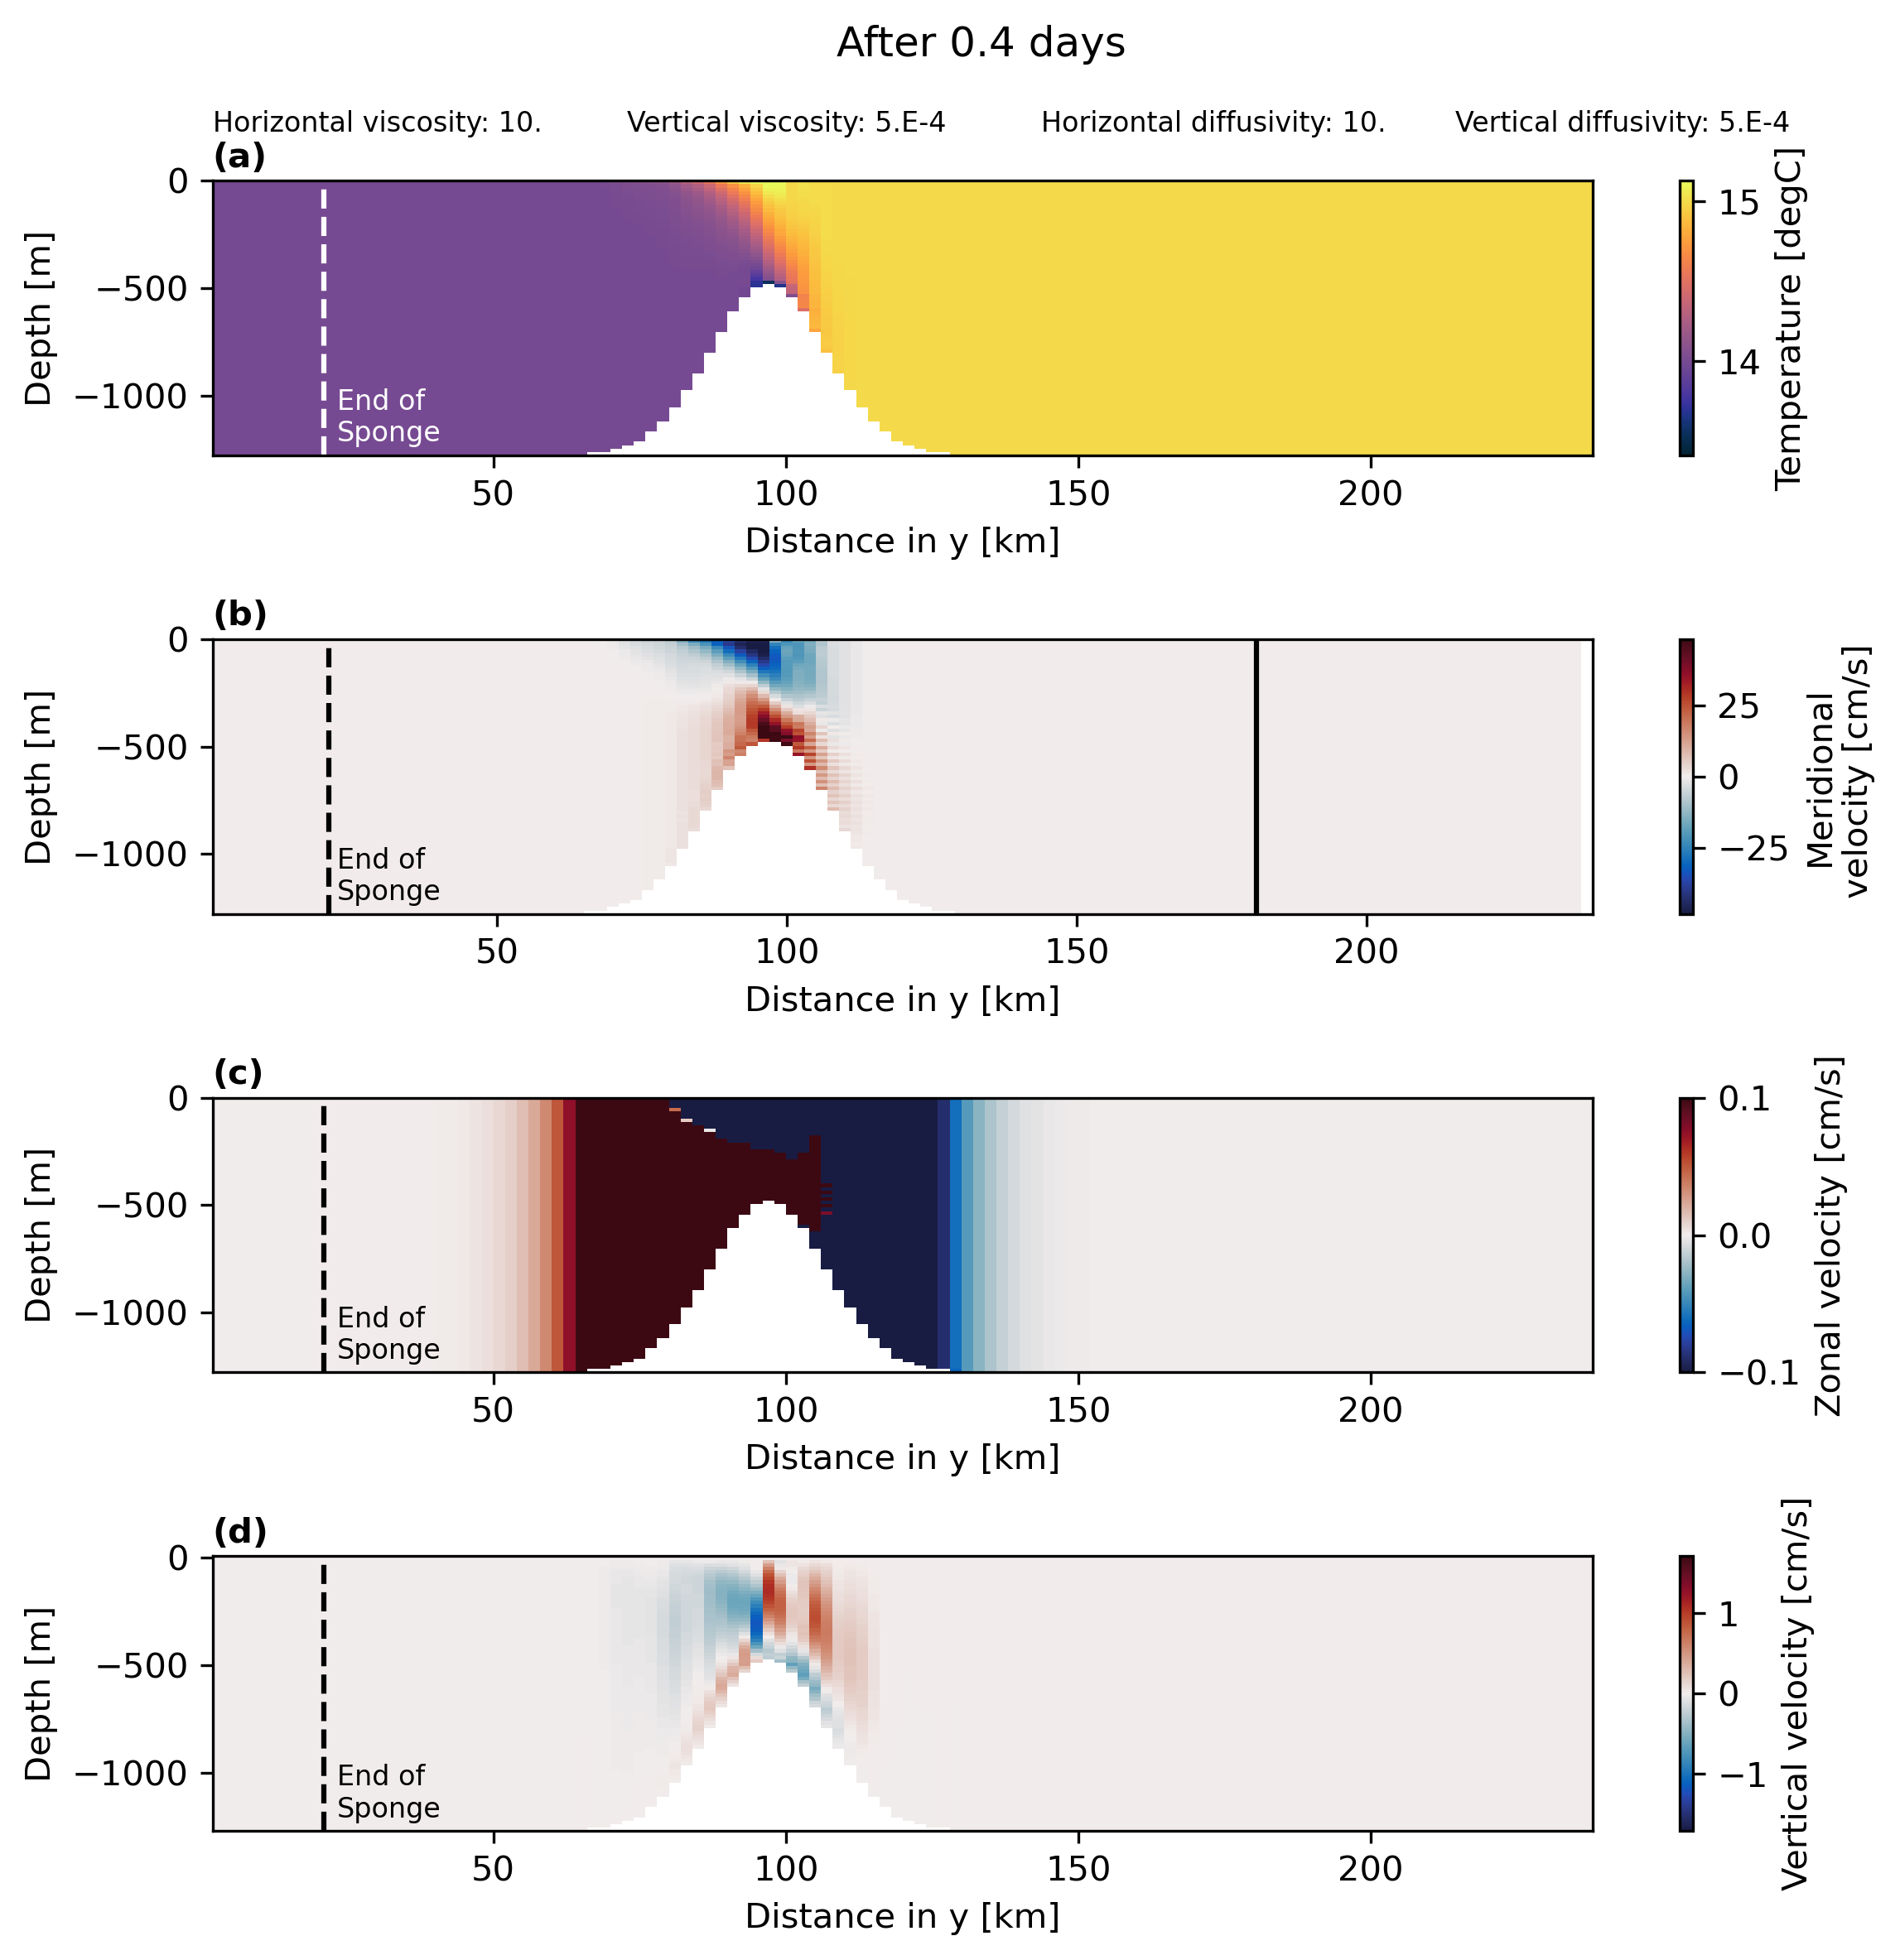

In [48]:
params = {'font.size': 10,
          'figure.figsize': (8, 8),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
tin=4
fig = plt.figure()
gs = GridSpec(nrows=4, ncols=1)
axin = fig.add_subplot(gs[0, 0])
axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

T=np.mean(ds.THETA[:,:,:,OBx:OBendx],axis=3)
Yin=dsG.Y[OBp:OBendp]
Zin=dsG.Z

vmin=np.min(np.ma.masked_array(T[tin,:,OB:OBend],mask=mask[:,OB:OBend,1]))
vmax=np.max(np.ma.masked_array(T[tin,:,OB:OBend],mask=mask[:,OB:OBend,1]))
cmapi=cmocean.cm.thermal


timein=ds.T[tin]/(60*60*24*360)
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp],mask=mask[:,OBp:OBendp,1]),vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp]),levels=[15,15.02,15.08,15.2,15.5],colors='cyan')
#plt.clabel(caxC, inline=1, fontsize=8)
cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Temperature [degC]')

axin.text(0, 1.05, '(a)', fontweight='bold', color='k', 
        transform=axin.transAxes)

axin.axvline(ds.Y[OB]/1000,c='white',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

s=1.18
for i in range(len(plotNames)):
    if i>3:
        s=1.15
        i=i-2
    axin.text(0+i*0.3, s, f'{plotNames[i]}: {plotValues[i]}', color='black', 
            transform=axin.transAxes,fontsize=8)

    
#axin.set_title(f'{plotNames[0]}:{plotValues[0]}, {plotNames[1]}:{plotValues[1]}\n {plotNames[2]}:{plotValues[2]}, {plotNames[3]}:{plotValues[3]}',fontsize=10)


axin = fig.add_subplot(gs[1, 0])

V=np.mean(ds.VVEL.values[:,:,:,OBx:OBendx],axis=3)

Yin=ds.Yp1[OBp:OBendp]

vmin=np.min(np.ma.masked_array(V[tin,:,OB:OBend]*100,mask=masks[:,OB:OBend,1]))/divV
vmax=-np.min(np.ma.masked_array(V[tin,:,OB:OBend]*100,mask=masks[:,OB:OBend,1]))/divV
cmapi=cmocean.cm.balance


axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

timein=ds.T[-tin]/(60*60*24)
cax1=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(V[tin,:,OBp:OBendp]*100,mask=masks[:,OBp:OBendp,1]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax1)
axin.axvline(ds.Y[int(0.75*ny)]/1000,c='k')
cbar_ax.set_label('Meridional\n velocity [cm/s]')




axin.text(0, 1.05, '(b)', fontweight='bold', color='k', 
        transform=axin.transAxes)

axin.axvline(ds.Y[OB]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

axin = fig.add_subplot(gs[2, 0])

U=np.mean(ds.UVEL[:,:,:,2:-2],axis=3)
Yin=ds.Y[OBp:OBendp]

vmin=np.min(np.ma.masked_array(U[tin,:,OB:OBend],mask=maskw[:,OB:OBend,1])*100)/0.1
vmax=-np.min(np.ma.masked_array(U[tin,:,OB:OBend],mask=maskw[:,OB:OBend,1])*100)/0.1
cmapi=cmocean.cm.balance



axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

timein=ds.T[-tin]/(60*60*24)
cax2=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(U[tin,:,OBp:OBendp]*100,mask=maskw[:,OBp:OBendp,1]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax2)
cbar_ax.set_label('Zonal velocity [cm/s]')


axin.text(0, 1.05, '(c)', fontweight='bold', color='k', 
        transform=axin.transAxes)

axin.axvline(ds.Y[OB]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)



W=np.mean(ds.WVEL.values[:,:,:,OBx:OBendx],axis=3)

Yin=dsG.Y[OBp:OBendp]
Zin=dsG.Zl

vmin=np.min(np.ma.masked_array(W[tin,:,OB:OBend]*100,mask=mask[:,OB:OBend,1]))/divW
vmax=-np.min(np.ma.masked_array(W[tin,:,OB:OBend]*100,mask=mask[:,OB:OBend,1]))/divW
cmapi=cmocean.cm.balance

axin = fig.add_subplot(gs[3, 0])

axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

timein=ds.T[-tin]/(60*60*24)
cax3=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(W[tin,:,OBp:OBendp]*100,mask=mask[:,OBp:OBendp,1]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax3)
cbar_ax.set_label('Vertical velocity [cm/s]')

axin.axvline(ds.Y[OB]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

axin.text(0, 1.05, '(d)', fontweight='bold', color='k', 
        transform=axin.transAxes)
tt=0
fig.suptitle(f'After {tt:.1f} days')

fig.tight_layout()
anim = FuncAnimation(fig, animatemean,frames=np.arange(0,len(ds.T.values),1), repeat=False,interval=600)

anim.save('../' + str(project)+'/Figures/' +str(ed)+ 'Meancrossects'  +'viscHor'+str(plotValues[0])+'viscVert'+str(plotValues[1])+'diffHor'+str(plotValues[2]) +'diffVert'+str(plotValues[3])+ '.mp4', writer=writer, dpi=600)


## On the sill

In [50]:
def animateX(t):
    tt=((ds.T.values[t])/(60*60*24))
    cax0.set_array(np.ma.masked_array(T[t,:,umb,OBx:OBendx],mask=mask[:bottom,umb,OBx:OBendx]))
    cax1.set_array(np.ma.masked_array(V[t,:,umb,OBx:OBendx]*100,mask=masks[:bottom,umb,OBx:OBendx]))
    cax2.set_array(np.ma.masked_array(U[t,:,umb,OBx+1:OBendx-1]*100,mask=maskw[:bottom,umb,OBx+1:OBendx-1]))
    cax3.set_array(np.ma.masked_array(W[t,:,umb,OBx:OBendx]*100,mask=mask[:bottom,umb,OBx:OBendx]))
    fig.suptitle(f'After {tt:.1f} days')



In [58]:
ds.THETA[10,:,umb,5].values!=0

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False])

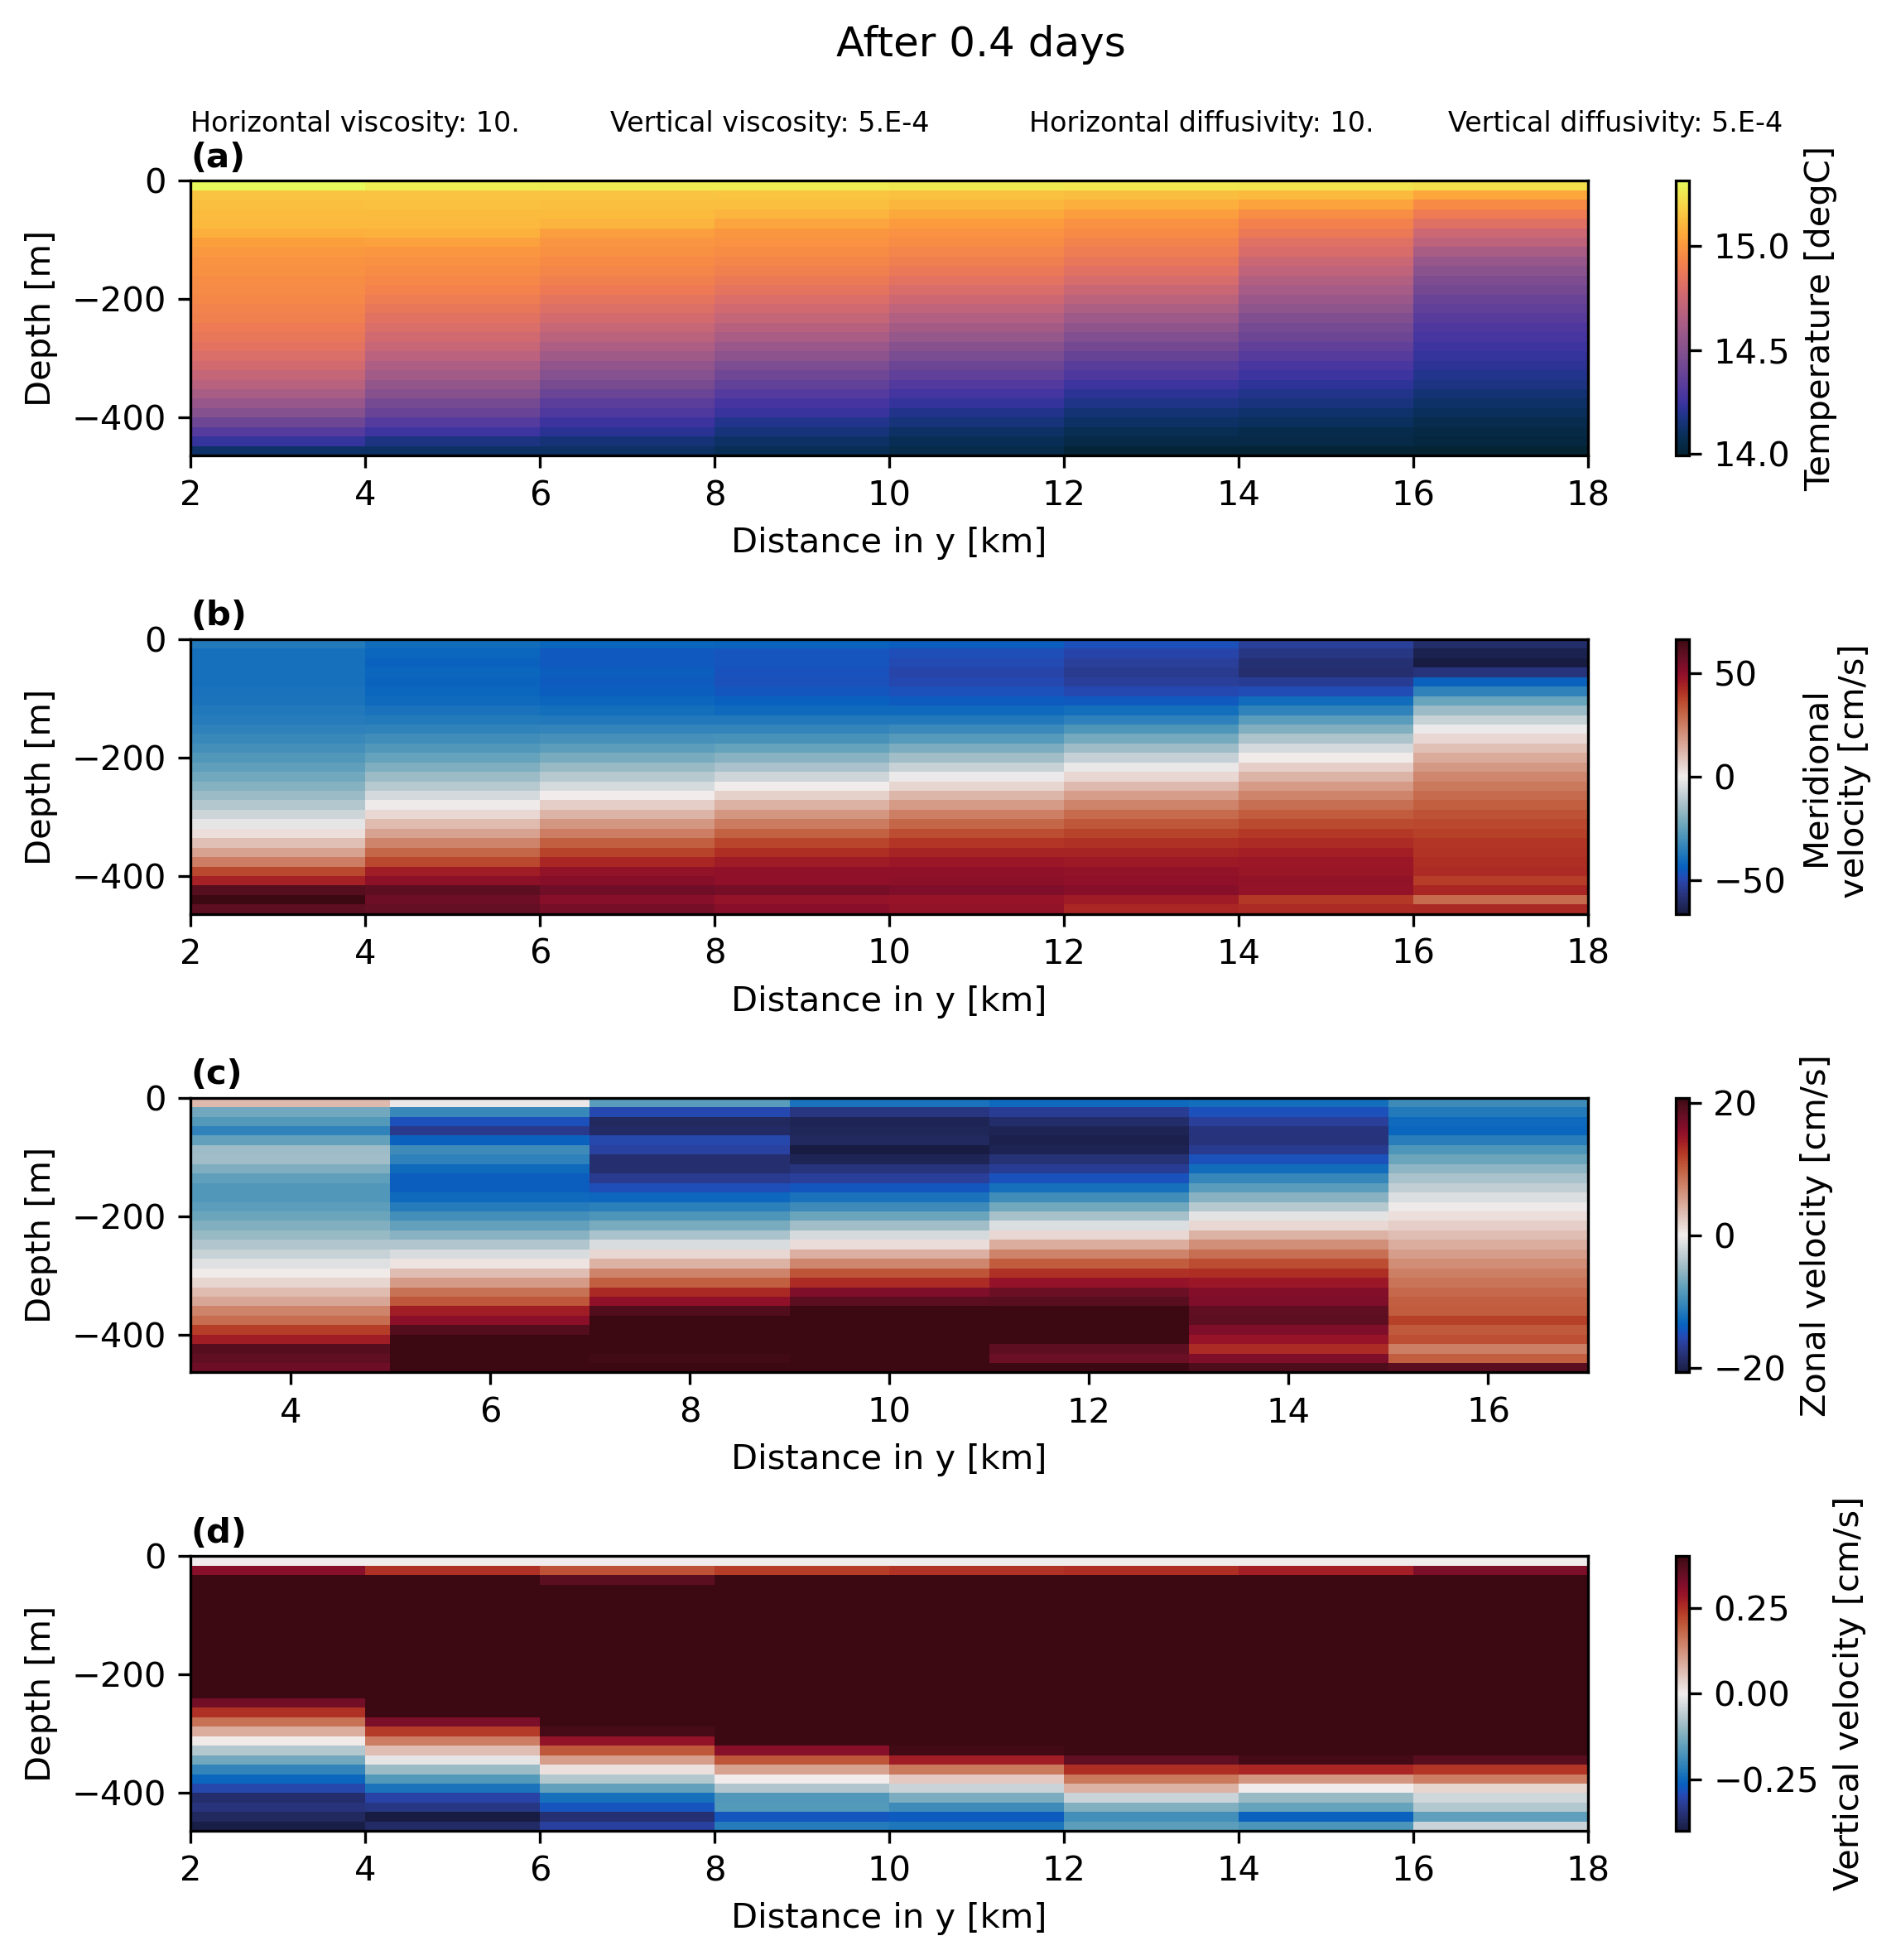

In [60]:
params = {'font.size': 10,
          'figure.figsize': (8, 8),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
tin=0
fig = plt.figure()
gs = GridSpec(nrows=4, ncols=1)
axin = fig.add_subplot(gs[0, 0])
axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

umb=int(len(dsG.Y)*0.4)
bottom=np.where(ds.THETA[tin,:,umb,5].values!=0)[0][-1]

T=ds.THETA[:,:bottom,:,:]
Xin=dsG.X[OBx:OBendx]
Zin=dsG.Z[:bottom]




vmin=np.min(np.ma.masked_array(T[tin,:,umb,OBx:OBendx],mask=mask[:bottom,umb,OBx:OBendx]))
vmax=np.max(np.ma.masked_array(T[tin,:,umb,OBx:OBendx],mask=mask[:bottom,umb,OBx:OBendx]))
cmapi=cmocean.cm.thermal


timein=ds.T[tin]/(60*60*24*360)
cax0=axin.pcolormesh(Xin/1000, Zin, np.ma.masked_array(T[tin,:,umb,OBx:OBendx],mask=mask[:bottom,umb,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, np.ma.masked_array(T[tin,:,umb,OBx:OBendx]),levels=[15,15.02,15.08,15.2,15.5],colors='cyan')
#plt.clabel(caxC, inline=1, fontsize=8)
cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Temperature [degC]')

axin.text(0, 1.05, '(a)', fontweight='bold', color='k', 
        transform=axin.transAxes)

s=1.18
for i in range(len(plotNames)):
    if i>3:
        s=1.15
        i=i-2
    axin.text(0+i*0.3, s, f'{plotNames[i]}: {plotValues[i]}', color='black', 
            transform=axin.transAxes,fontsize=8)

    
#axin.set_title(f'{plotNames[0]}:{plotValues[0]}, {plotNames[1]}:{plotValues[1]}\n {plotNames[2]}:{plotValues[2]}, {plotNames[3]}:{plotValues[3]}',fontsize=10)


axin = fig.add_subplot(gs[1, 0])

V=ds.VVEL.values[:,:bottom,:,:]

Xin=ds.X[OBx:OBendx]

vmin=np.min(np.ma.masked_array(V[tin,:,umb,OBx:OBendx]*100,mask=masks[:bottom,umb,OBx:OBendx]))/divV
vmax=-np.min(np.ma.masked_array(V[tin,:,umb,OBx:OBendx]*100,mask=masks[:bottom,umb,OBx:OBendx]))/divV
cmapi=cmocean.cm.balance


axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

timein=ds.T[-tin]/(60*60*24)
cax1=axin.pcolormesh(Xin/1000, Zin, np.ma.masked_array(V[tin,:,umb,OBx:OBendx]*100,mask=masks[:bottom,umb,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax1)
cbar_ax.set_label('Meridional\n velocity [cm/s]')


axin.text(0, 1.05, '(b)', fontweight='bold', color='k', 
        transform=axin.transAxes)


axin = fig.add_subplot(gs[2, 0])

U=ds.UVEL[:,:bottom,:,:]

Xin=ds.Xp1[OBx+1:OBendx-1]

vmin=np.min(np.ma.masked_array(U[tin,:,umb,OBx+1:OBendx-1],mask=maskw[:bottom,umb,OBx+1:OBendx-1])*100)/divU
vmax=-np.min(np.ma.masked_array(U[tin,:,umb,OBx+1:OBendx-1],mask=maskw[:bottom,umb,OBx+1:OBendx-1])*100)/divU
cmapi=cmocean.cm.balance



axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

timein=ds.T[-tin]/(60*60*24)
cax2=axin.pcolormesh(Xin/1000, Zin, np.ma.masked_array(U[tin,:,umb,OBx+1:OBendx-1]*100,mask=maskw[:bottom,umb,OBx+1:OBendx-1]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax2)
cbar_ax.set_label('Zonal velocity [cm/s]')


axin.text(0, 1.05, '(c)', fontweight='bold', color='k', 
        transform=axin.transAxes)



W=ds.WVEL.values[:,:bottom,:,:] 
Xin=dsG.X[OBx:OBendx]
Zin=dsG.Z[:bottom]

vmin=np.min(np.ma.masked_array(W[tin,:,umb,OBx:OBendx]*100,mask=mask[:bottom,umb,OBx:OBendx]))/divW
vmax=-np.min(np.ma.masked_array(W[tin,:,umb,OBx:OBendx]*100,mask=mask[:bottom,umb,OBx:OBendx]))/divW
cmapi=cmocean.cm.balance

axin = fig.add_subplot(gs[3, 0])

axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

timein=ds.T[-tin]/(60*60*24)
cax3=axin.pcolormesh(Xin/1000, Zin, np.ma.masked_array(W[tin,:,umb,OBx:OBendx]*100,mask=mask[:bottom,umb,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax3)
cbar_ax.set_label('Vertical velocity [cm/s]')


axin.text(0, 1.05, '(d)', fontweight='bold', color='k', 
        transform=axin.transAxes)
tt=0
fig.suptitle(f'After {tt:.1f} days')

fig.tight_layout()
anim = FuncAnimation(fig, animateX,frames=np.arange(0,len(ds.T.values),1), repeat=False,interval=600)

anim.save('../' + str(project)+'/Figures/' +str(ed)+ 'crossectsX'  +'viscHor'+str(plotValues[0])+'viscVert'+str(plotValues[1])+'diffHor'+str(plotValues[2]) +'diffVert'+str(plotValues[3])+ '.mp4', writer=writer, dpi=600)


In [194]:
#Rho Linear EOS
alpha=2*1e-4
RHO=np.zeros(np.shape(ds.THETA.values))
for i in range(len(ds.T)):
    RHO[i,:,:,:]=-999.8*np.ma.masked_array(ds.THETA[i].values-15,mask=mask)*alpha

In [205]:
from math import sin

In [206]:
lat=(22.92+31.70)/2

omega=7.2921*(10**(-5))

f=2*omega*sin(np.deg2rad(lat))

In [207]:
np.sqrt((9.8*(((999.8*15*alpha)-(999.8*14*alpha))/999.8)*200))/f

9356.913622070515

In [69]:
def BottomConc(vel, hfac, nz,nt, ny,loc):
    '''vel: Velocity field (nt,nz,ny)
       hfac: fraction of open cell at center (nz,ny)
       
       
       RETURNS:
       
       BotVel = velocity near bottom (nt,ny)'''
    
    BotVel = np.empty((nt,ny))
    BottomInd = np.argmax(hfac[::-1,:]>0.0,axis=0) # start looking for first no-land cell from the bottom up.
    BottomInd = (np.ones(np.shape(BottomInd))*nz - BottomInd)-loc # Get index of unreversed z axis
    
    for j in range(nt):
        for i in range(ny): 
            BotVel[j,i] = vel[j,int(BottomInd[i]),i] 
                
    
    return (BotVel,BottomInd)


In [70]:
velout1,BottomInd1=BottomConc(V[:,:,:,0],hFacS[:,:,0].values , nz, nt, ny+1,1)
velout2,BottomInd2=BottomConc(V[:,:,:,0],hFacS[:,:,0].values , nz, nt, ny+1,2)

Wvelout1,BottomInd=BottomConc(W[:,:,:,0],hFacC[:,:,0].values , nz, nt, ny,1)
Wvelout2,BottomInd=BottomConc(W[:,:,:,0],hFacC[:,:,0].values , nz, nt, ny,20)

Rhoout1,BottomInd=BottomConc(RHO[:,:,:,0],hFacC[:,:,0].values , nz, nt, ny,1)
Rhoout2,BottomInd=BottomConc(RHO[:,:,:,0],hFacC[:,:,0].values , nz, nt, ny,20)

In [71]:
params = {'font.size': 14,
          'figure.figsize': (12, 12),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [72]:
tin=np.where(ds.T/(24*60*60*360)>9)[0][0]
tinplot=np.where(ds.T/(24*60*60*360)>0)[0][0]

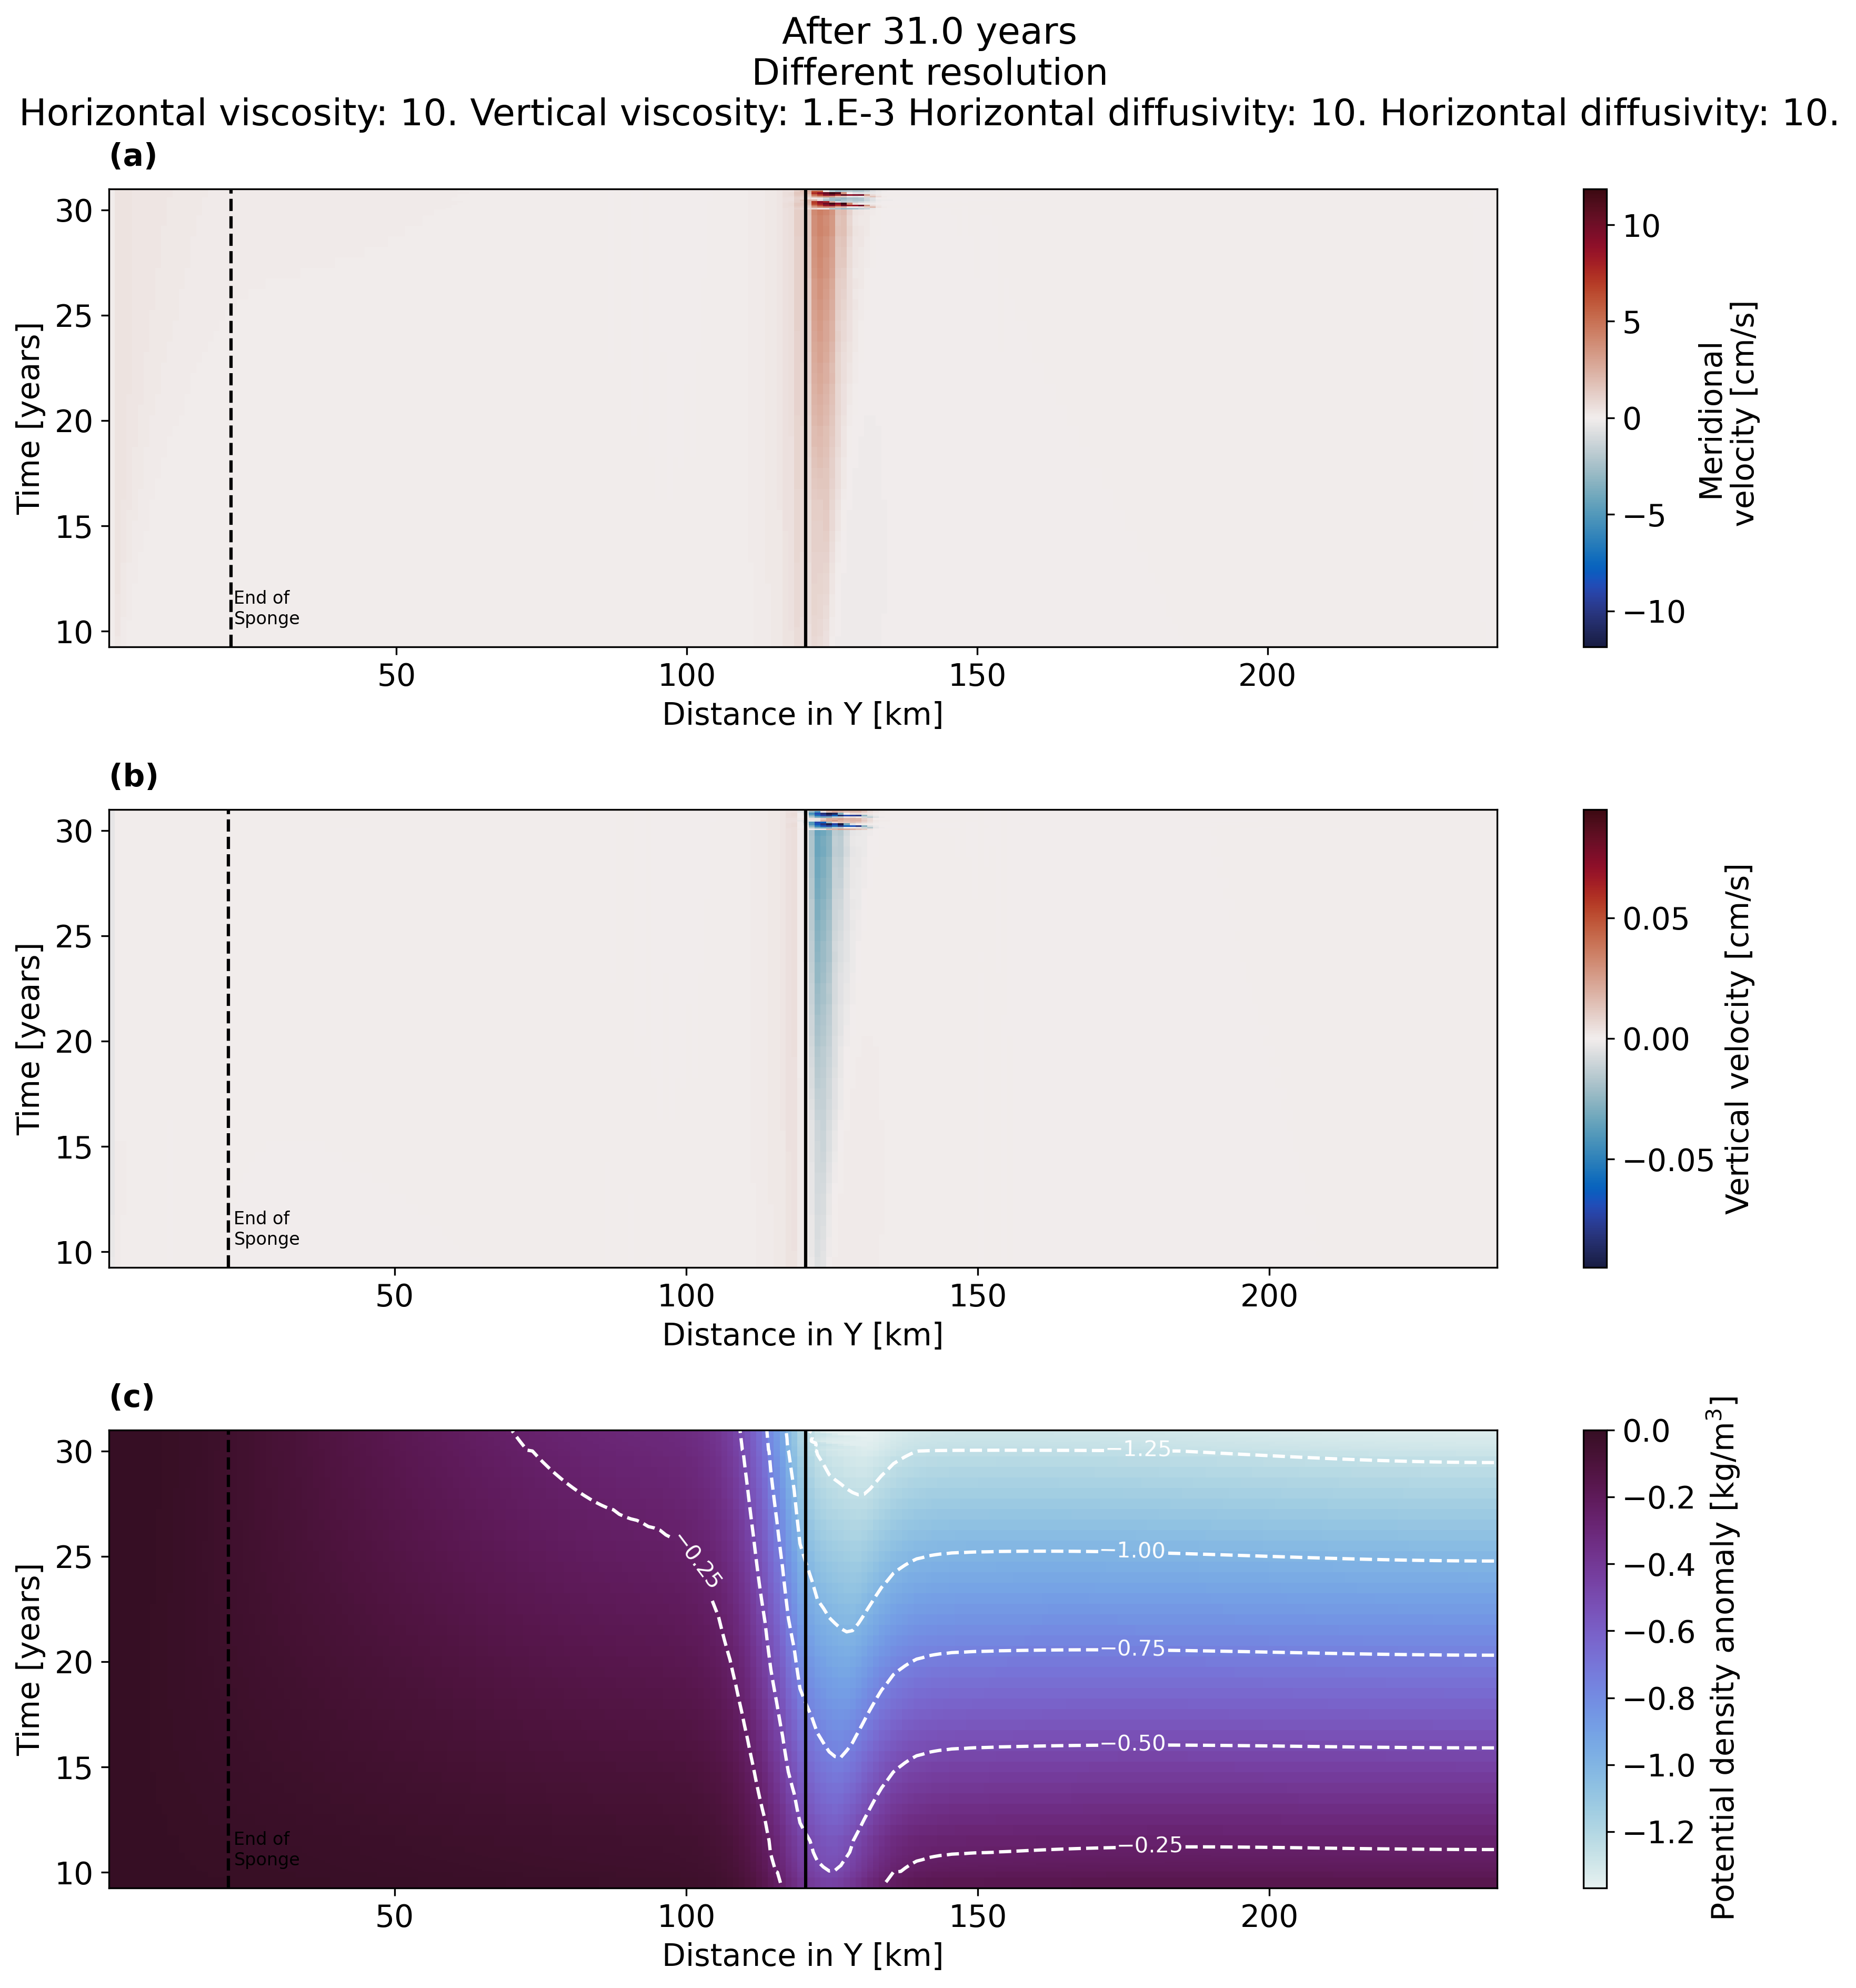

In [73]:
## Hovmöller ##

t=ds.T[tin:]/(60*60*24*360)

fig = plt.figure()
gs = GridSpec(nrows=3, ncols=1)

axin = fig.add_subplot(gs[0, 0])

Yin=ds.Yp1[OBp:OBendp]

vmin=-np.max(velout1[tinplot:,OB:OBend]*100)/divV
vmax=np.max(velout1[tinplot:,OB:OBend]*100)/divV
cmapi=cmocean.cm.balance

cax0=axin.pcolormesh(Yin/1000, t, velout1[tin:,OBp:OBendp]*100,vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax0)
axin.set(ylabel='Time [years]',xlabel='Distance in Y [km]')
cbar_ax.set_label('Meridional\n velocity [cm/s]')

axin.axvline(ds.Y[int(umbral)]/1000,c='k')
axin.text(0, 1.05, '(a)', fontweight='bold', color='k',
        transform=axin.transAxes)
axin.axvline(ds.Y[OB]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

#axin.axhline(31,c='k',linestyle='dashed')
#axin.text(0.7, 0.35, 'Above output is averaged over 10 days\n\nBelow  output is instantaneous snapshot\nevery 10 days', color='k', 
#        transform=axin.transAxes,fontsize=8)

axin = fig.add_subplot(gs[1, 0])


Yin=ds.Y[OBp:OBendp]

vmin=np.min(Wvelout1[tinplot:,OB:OBend]*100)/divW
vmax=-np.min(Wvelout1[tinplot:,OB:OBend]*100)/divW
cmapi=cmocean.cm.balance

axin.set(ylabel='Time [years]',xlabel='Distance in Y [km]')

cax0=axin.pcolormesh(Yin/1000,t, Wvelout1[tin:,OBp:OBendp]*100,vmin=vmin,vmax=vmax,cmap=cmapi)
cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Vertical velocity [cm/s]')

axin.axvline(ds.Y[int(umbral)]/1000,c='k')
axin.text(0, 1.05, '(b)', fontweight='bold', color='k',
        transform=axin.transAxes)

axin.axvline(ds.Y[OB]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

#axin.axhline(31,c='k',linestyle='dashed')
#axin.text(0.7, 0.35, 'Above output is averaged over 10 days\n\nBelow  output is instantaneous snapshot\nevery 10 days', color='k', 
 #       transform=axin.transAxes,fontsize=8)

axin = fig.add_subplot(gs[2, 0])


Yin=ds.Y[OBp:OBendp]

vmin=np.min(Rhoout1[tinplot:,OB:OBend])
vmax=np.max(Rhoout1[tinplot:,OB:OBend])
cmapi=cmocean.cm.dense

levels=np.linspace(vmin,vmax,15)

axin.set(ylabel='Time [years]',xlabel='Distance in Y [km]')

cax0=axin.pcolormesh(Yin/1000,t, Rhoout1[tin:,OBp:OBendp],vmin=vmin,vmax=vmax,cmap=cmapi)
contours=axin.contour(Yin/1000,t, Rhoout1[tin:,OBp:OBendp],levels=5,colors='white') #np.flip([-0.9,-0.925,-0.95,-1,-1.05])
plt.clabel(contours, inline=1, fontsize=10)
cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Potential density anomaly [kg/m$^3$]')


axin.text(0, 1.05, '(c)', fontweight='bold', color='k',
        transform=axin.transAxes)

axin.axvline(ds.Y[OB]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)
axin.axvline(ds.Y[int(umbral)]/1000,c='k')
    
fig.tight_layout()
fig.suptitle(f'After {t[-1]:.1f} years\n Different resolution \n{plotNames[0]}: {plotValues[0]} {plotNames[1]}: {plotValues[1]} {plotNames[2]}: {plotValues[2]} {plotNames[2]}: {plotValues[2]}',y=1.05)


plt.savefig('../' + str(project)+'/Figures/' +str(ed)+ 'LastYearhovmöller' +'viscHor'+str(plotValues[0])+'viscVert'+str(plotValues[1])+'diffHor'+str(plotValues[2]) +'diffVert'+str(plotValues[3])+ '.png',dpi=400)



In [175]:
params = {'font.size': 10,
          'figure.figsize': (8, 4),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [136]:
tinmerid=0

In [137]:
def animateLine(t):
    tt=(t+1+tinmerid)*((ds.T.values[1]-ds.T.values[0])/(60*60*24*360))
    pax1.set_ydata(velout1[t+tinmerid,OB:OBend]*100)
    pax2.set_ydata(velout2[t+tinmerid,OB:OBend]*100)
    fig.suptitle(f'After {tt:.1f} years')


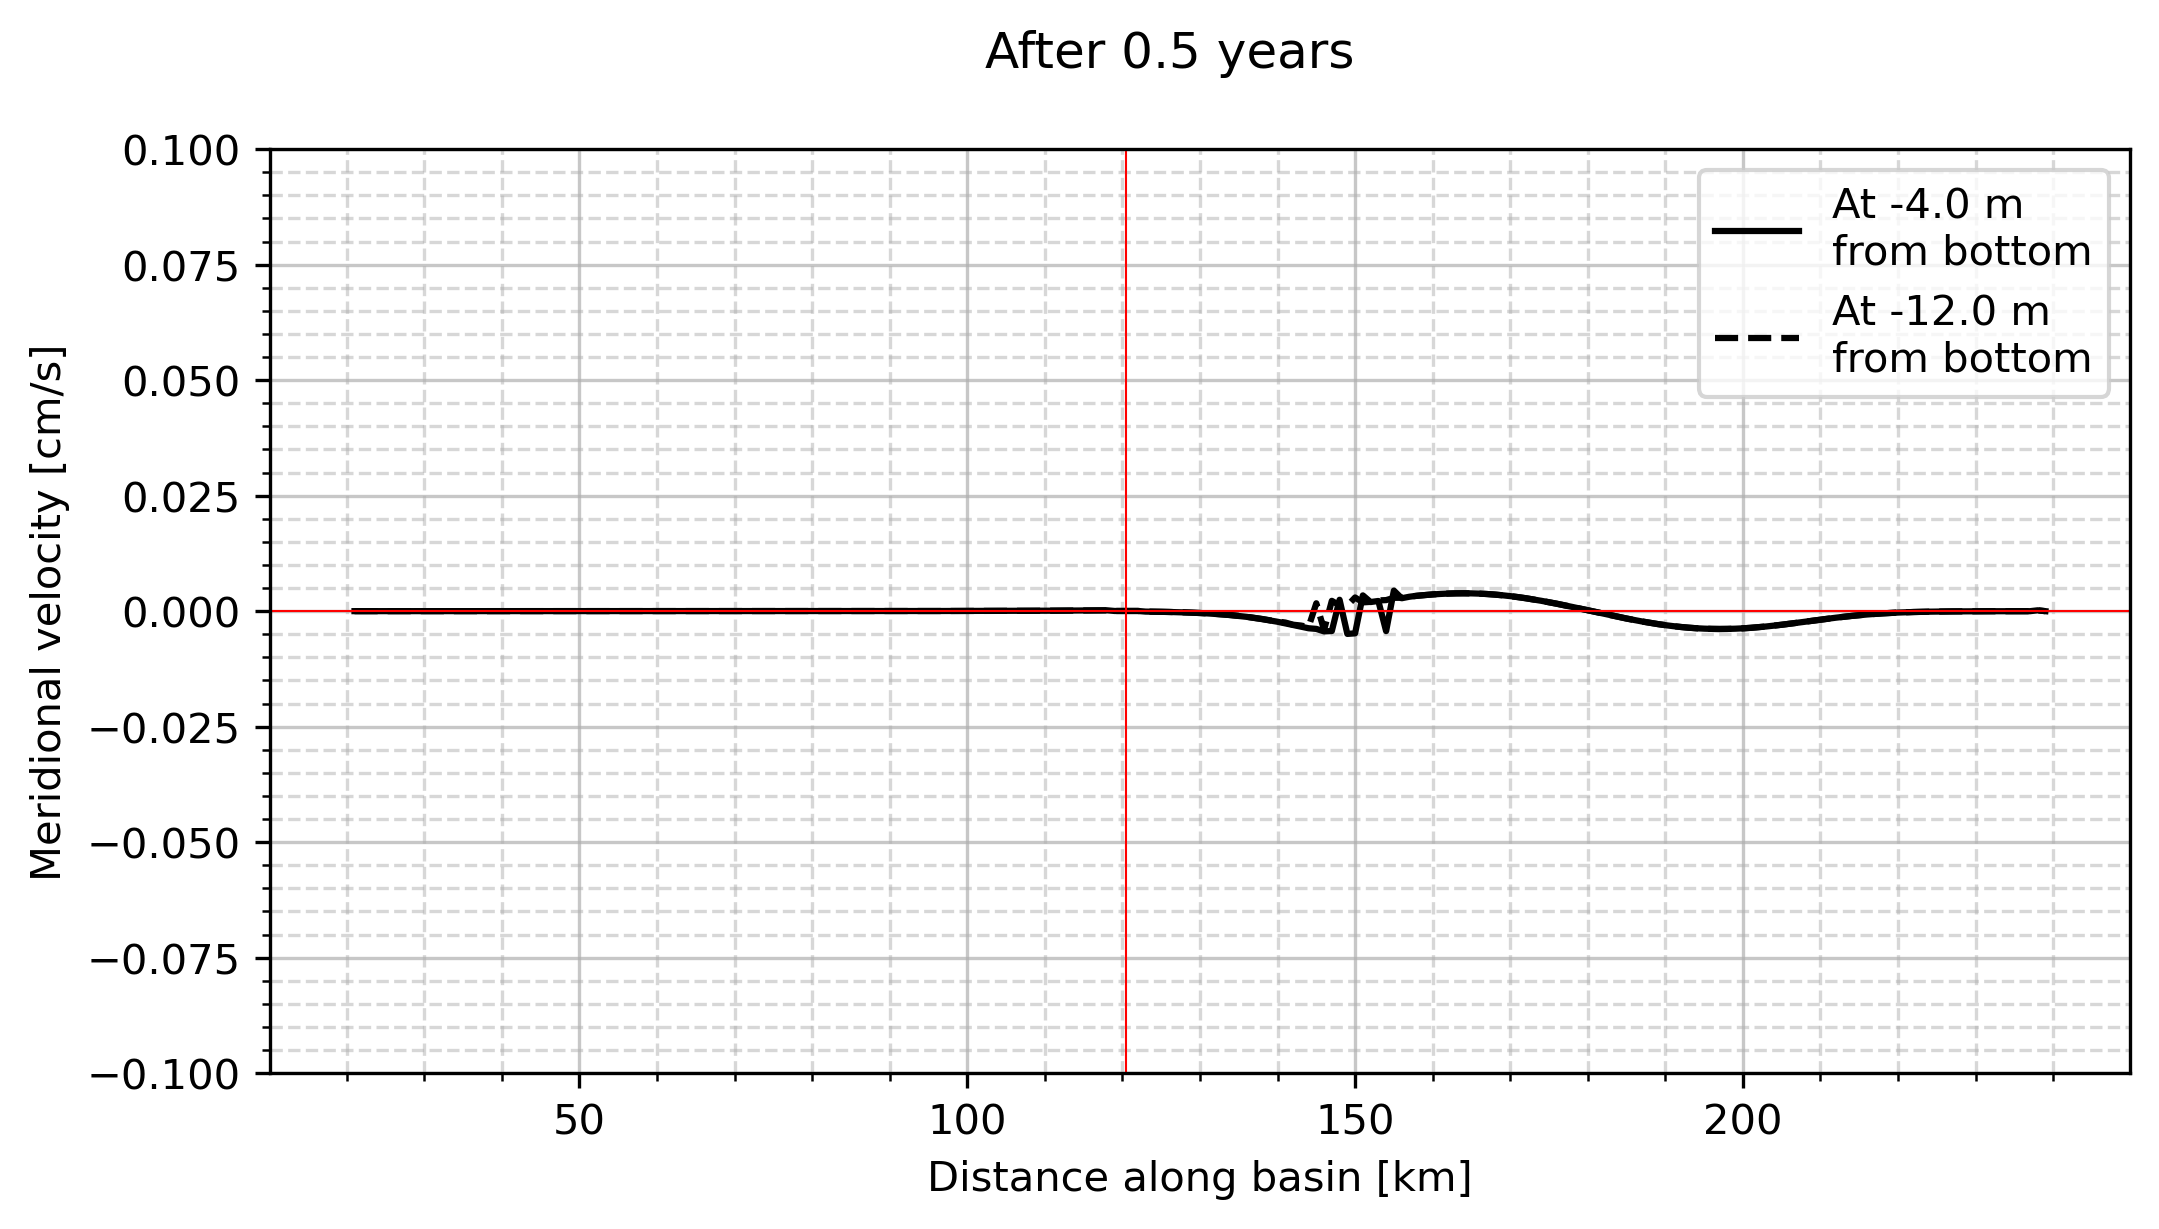

In [76]:
fig,ax=plt.subplots()
pax1,=ax.plot(ds.Yp1[OB:OBend]/1000,velout1[tinmerid,OB:OBend]*100,color='k', label=f'At {dsG.Z[0].values} m\nfrom bottom')
pax2,=ax.plot(ds.Yp1[OB:OBend]/1000,velout1[tinmerid,OB:OBend]*100,color='k',linestyle='dashed', label=f'At {dsG.Z[1].values} m\nfrom bottom')
ax.set(ylabel='Meridional velocity [cm/s]',xlabel='Distance along basin [km]')

tt=(1+tinmerid)*((ds.T.values[1]-ds.T.values[0])/(60*60*24))
fig.suptitle(f'After {tt:.1f} days')
    
ax.minorticks_on()

ax.grid(which='minor',linestyle='--', alpha=0.5)
ax.grid(which='major',alpha=0.7)
ax.legend()

ax.axvline(ds.Y[int(len(ds.Y)/2)]/1000,linewidth=0.5,color='red')
ax.axhline(0,linewidth=0.5,color='red')
ax.set_ylim((-0.1,0.1))
anim = FuncAnimation(fig, animateLine,frames=len(ds.T.values)-tinmerid, repeat=False)

anim.save('../' + str(project)+'/Figures/' +str(ed)+ 'MeridVel1' +'viscHor'+str(plotNames[0])+'viscVert'+str(plotNames[1])+'diffHor'+str(plotNames[2]) +'diffVert'+str(plotNames[3])+ '.mp4', writer=writer, dpi=600)



In [77]:
def animateLineW(t):
    tt=(t+1+tinmerid)*((ds.T.values[1]-ds.T.values[0])/(60*60*24*360))
    pax1.set_ydata(Wvelout1[t+tinmerid,OB:OBend]*100)
    pax2.set_ydata(Wvelout2[t+tinmerid,OB:OBend]*100)
    fig.suptitle(f'After {tt:.1f} years')


In [78]:
np.min(Wvelout2[-1,OB:OBend]*100)

-0.0003363928726685117

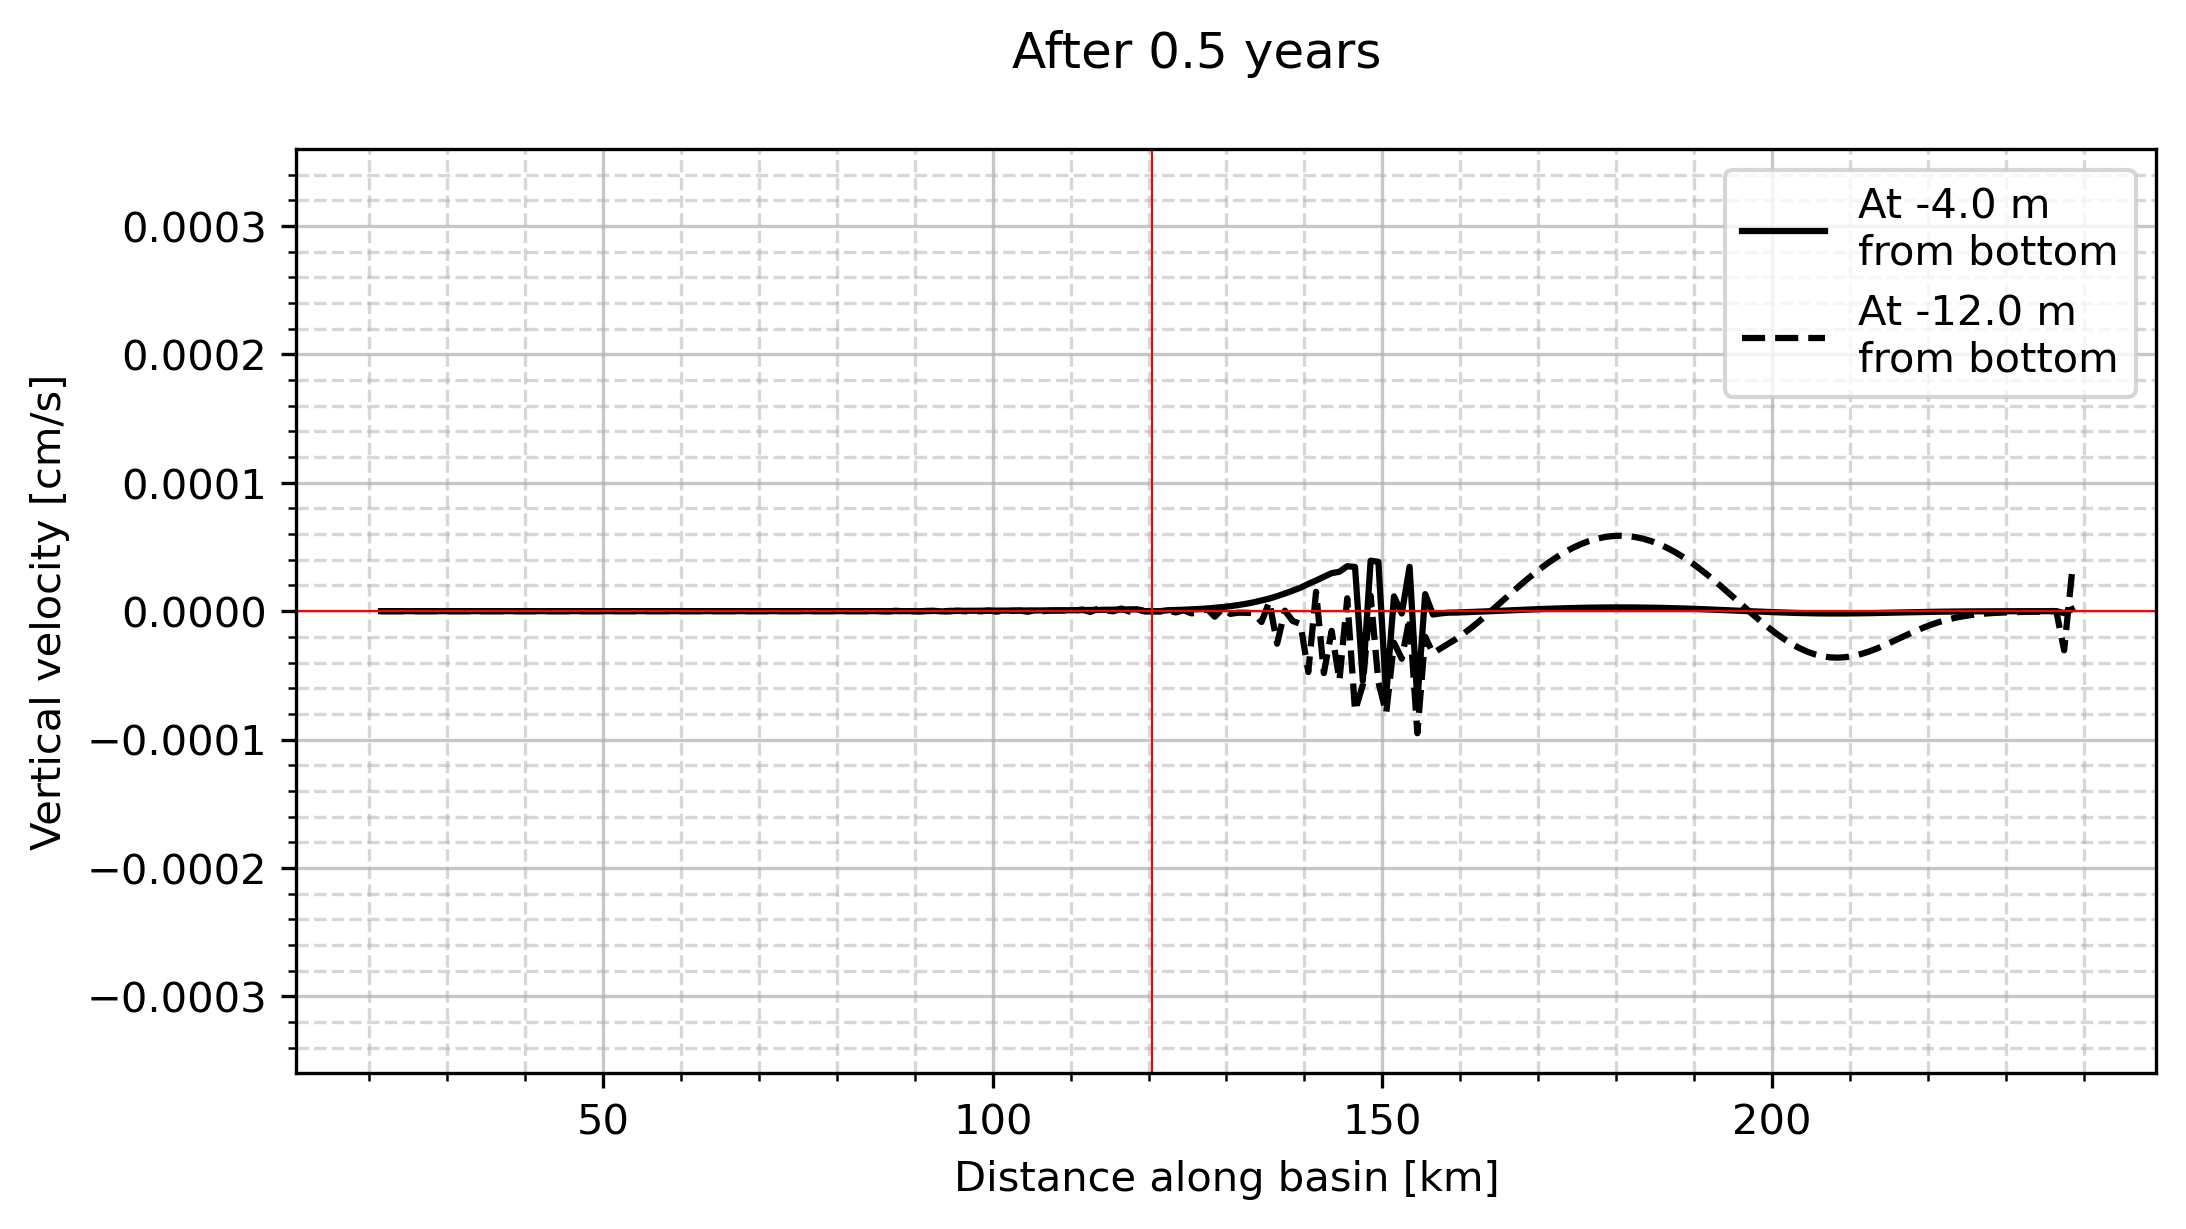

In [79]:
fig,ax=plt.subplots()
pax1,=ax.plot(ds.Y[OB:OBend]/1000,Wvelout1[tinmerid,OB:OBend]*100,color='k', label=f'At {dsG.Z[0].values} m\nfrom bottom')
pax2,=ax.plot(ds.Y[OB:OBend]/1000,Wvelout2[tinmerid,OB:OBend]*100,color='k',linestyle='dashed', label=f'At {dsG.Z[1].values} m\nfrom bottom')
ax.set(ylabel='Vertical velocity [cm/s]',xlabel='Distance along basin [km]')

tt=(1+tinmerid)*((ds.T.values[1]-ds.T.values[0])/(60*60*24))
fig.suptitle(f'After {tt:.1f} days')
    
ax.minorticks_on()

ax.grid(which='minor',linestyle='--', alpha=0.5)
ax.grid(which='major',alpha=0.7)

ax.axvline(ds.Y[int(len(ds.Y)/2)]/1000,linewidth=0.5,color='red')
ax.axhline(0,linewidth=0.5,color='red')
ax.legend()
ax.set_ylim((-np.max(Wvelout2[-1,OB:OBend]*100),np.max(Wvelout2[-1,OB:OBend]*100)))

anim = FuncAnimation(fig, animateLineW,frames=len(ds.T.values)-tinmerid, repeat=False)

anim.save('../' + str(project)+'/Figures/' +str(ed)+ 'VerticalVel' +'viscHor'+str(plotNames[0])+'viscVert'+str(plotNames[1])+'diffHor'+str(plotNames[2]) +'diffVert'+str(plotNames[3])+ '.mp4', writer=writer, dpi=600)



# State

In [176]:
varst='state'

dsst=xr.open_dataset(str(location) +  str(varst) + '.nc')

In [177]:
def animateState(t):
    tt=((dsst.T.values[t])/(60*60*24))
    cax0.set_array(np.ma.masked_array(T[t,:,OBp:OBendp,0],mask=mask[:,OBp:OBendp,0]))
    cax1.set_array(np.ma.masked_array(V[t,:,OBp:OBendp,0]*100,mask=masks[:,OBp:OBendp,0]))
    cax2.set_array(np.ma.masked_array(np.mean(U[t,:,OBp:OBendp,:],axis=2)*100,mask=maskw[:,OBp:OBendp,0]))
    cax3.set_array(np.ma.masked_array(W[t,:,OBp:OBendp,0]*100,mask=mask[:,OBp:OBendp,0]))
    fig.suptitle(f'After {tt:.1f} day')



In [178]:
divV=100
divU=1
divW=100

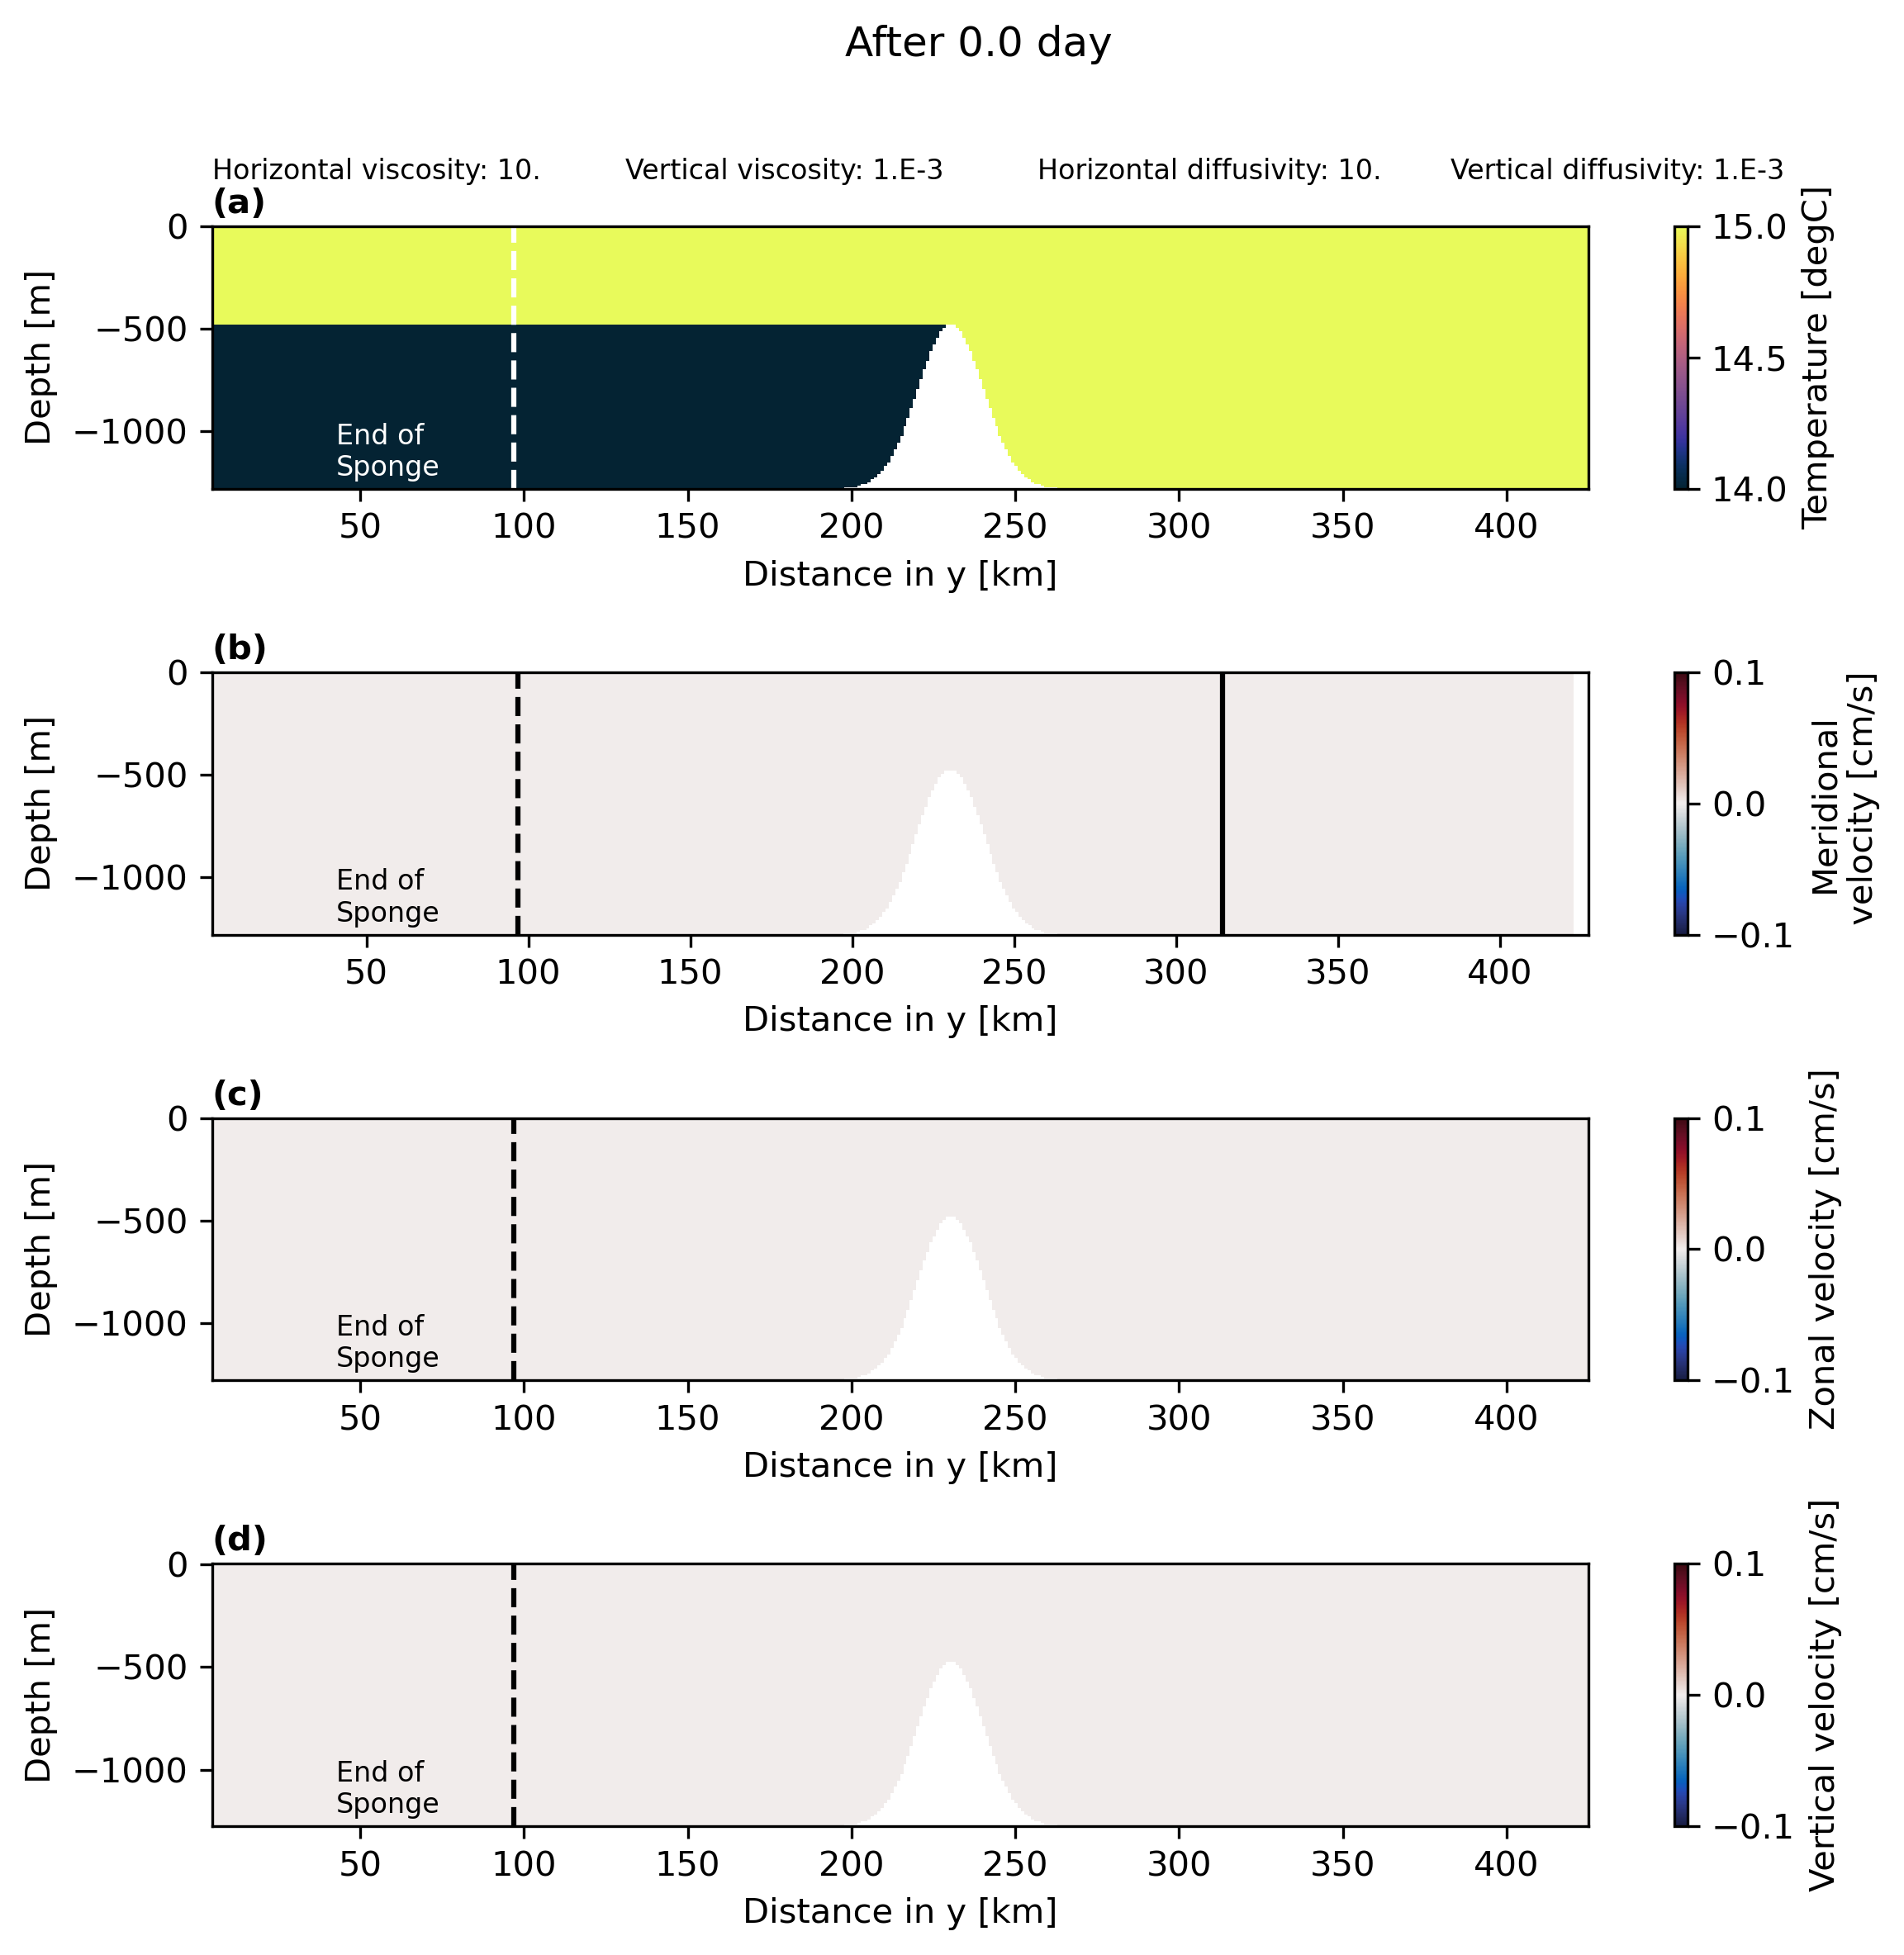

In [179]:
params = {'font.size': 10,
          'figure.figsize': (8, 8),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

fig = plt.figure()
gs = GridSpec(nrows=4, ncols=1)
axin = fig.add_subplot(gs[0, 0])
axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

T=dsst.Temp
Yin=dsG.Y[OBp:OBendp]
Zin=dsG.Z

vmin=np.min(np.ma.masked_array(T[tin,:,OB:OBend,0],mask=mask[:,OB:OBend,0]))
vmax=np.max(np.ma.masked_array(T[tin,:,OB:OBend,0],mask=mask[:,OB:OBend,0]))
cmapi=cmocean.cm.thermal


timein=dsst.T[tin]/(60*60*24)
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp,0],mask=mask[:,OBp:OBendp,0]),vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp,0]),levels=[15,15.02,15.08,15.2,15.5],colors='cyan')
#plt.clabel(caxC, inline=1, fontsize=8)
cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Temperature [degC]')

axin.text(0, 1.05, '(a)', fontweight='bold', color='k', 
        transform=axin.transAxes)

axin.axvline(ds.Y[20]/1000,c='white',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

s=1.18
for i in range(len(plotNames)):
    if i>3:
        s=1.15
        i=i-2
    axin.text(0+i*0.3, s, f'{plotNames[i]}: {plotValues[i]}', color='black', 
            transform=axin.transAxes,fontsize=8)

    
#axin.set_title(f'{plotNames[0]}:{plotValues[0]}, {plotNames[1]}:{plotValues[1]}\n {plotNames[2]}:{plotValues[2]}, {plotNames[3]}:{plotValues[3]}',fontsize=10)


axin = fig.add_subplot(gs[1, 0])

V=dsst.V.values

Yin=ds.Yp1[OBp:OBendp]

vmin=np.min(np.ma.masked_array(V[tin,:,OB:OBend,0]*100,mask=masks[:,OB:OBend,0]))/divV
vmax=-np.min(np.ma.masked_array(V[tin,:,OB:OBend,0]*100,mask=masks[:,OB:OBend,0]))/divV
cmapi=cmocean.cm.balance


axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

cax1=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(V[tin,:,OBp:OBendp,0]*100,mask=masks[:,OBp:OBendp,0]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax1)
axin.axvline(ds.Y[int(0.75*ny)]/1000,c='k')
cbar_ax.set_label('Meridional\n velocity [cm/s]')


axin.text(0, 1.05, '(b)', fontweight='bold', color='k', 
        transform=axin.transAxes)

axin.axvline(ds.Y[20]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

axin = fig.add_subplot(gs[2, 0])

U=dsst.U

Yin=ds.Y[OBp:OBendp]

vmin=np.min(np.ma.masked_array(np.mean(U[tin,:,OB:OBend,:],axis=2))*100)/divU
vmax=-np.min(np.ma.masked_array(np.mean(U[tin,:,OB:OBend,:],axis=2))*100)/divU
cmapi=cmocean.cm.balance



axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')


cax2=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(np.mean(U[tin,:,OBp:OBendp,:],axis=2)*100,mask=maskw[:,OBp:OBendp,0]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax2)
cbar_ax.set_label('Zonal velocity [cm/s]')


axin.text(0, 1.05, '(c)', fontweight='bold', color='k', 
        transform=axin.transAxes)

axin.axvline(ds.Y[20]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)



W=dsst.W.values

Yin=dsG.Y[OBp:OBendp]
Zin=dsG.Zl

vmin=np.min(np.ma.masked_array(W[tin,:,OB:OBend,0]*100,mask=mask[:,OB:OBend,0]))/divW
vmax=-np.min(np.ma.masked_array(W[tin,:,OB:OBend,0]*100,mask=mask[:,OB:OBend,0]))/divW
cmapi=cmocean.cm.balance

axin = fig.add_subplot(gs[3, 0])

axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')


cax3=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(W[tin,:,OBp:OBendp,0]*100,mask=mask[:,OBp:OBendp,0]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax3)
cbar_ax.set_label('Vertical velocity [cm/s]')

axin.axvline(ds.Y[20]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

axin.text(0, 1.05, '(d)', fontweight='bold', color='k', 
        transform=axin.transAxes)
tt=0
fig.suptitle(f'After {tt:.1f} years \n Different resolution')

fig.tight_layout()
anim = FuncAnimation(fig, animateState,frames=np.arange(0,len(dsst.T.values),1), repeat=False,interval=600)

anim.save('../' + str(project)+'/Figures/' +str(ed)+ 'StatedifRescrossects'  +'viscHor'+str(plotValues[0])+'viscVert'+str(plotValues[1])+'diffHor'+str(plotValues[2]) +'diffVert'+str(plotValues[3])+ '.mp4', writer=writer, dpi=600)


In [180]:
#Rho Linear EOS
alpha=2*1e-4
RHO=np.zeros(np.shape(dsst.Temp.values))
for i in range(len(ds.T)):
    RHO[i,:,:,:]=-999.8*np.ma.masked_array(dsst.Temp[i].values-15,mask=mask)*alpha

In [181]:
def BottomConc(vel, hfac, nz,nt, ny,loc):
    '''vel: Velocity field (nt,nz,ny)
       hfac: fraction of open cell at center (nz,ny)
       
       
       RETURNS:
       
       BotVel = velocity near bottom (nt,ny)'''
    
    BotVel = np.empty((nt,ny))
    BottomInd = np.argmax(hfac[::-1,:]>0.0,axis=0) # start looking for first no-land cell from the bottom up.
    BottomInd = (np.ones(np.shape(BottomInd))*nz - BottomInd)-loc # Get index of unreversed z axis
    
    for j in range(nt):
        for i in range(ny): 
            BotVel[j,i] = vel[j,int(BottomInd[i]),i] 
                
    
    return (BotVel,BottomInd)


In [184]:
velout1,BottomInd1=BottomConc(V[:,:,:,0],hFacS[:,:,0].values , nz, nt+3, ny+1,1)
velout2,BottomInd2=BottomConc(V[:,:,:,0],hFacS[:,:,0].values , nz, nt+3, ny+1,2)

Wvelout1,BottomInd=BottomConc(W[:,:,:,0],hFacC[:,:,0].values , nz, nt+3, ny,1)
Wvelout2,BottomInd=BottomConc(W[:,:,:,0],hFacC[:,:,0].values , nz, nt+3, ny,20)

Rhoout1,BottomInd=BottomConc(RHO[:,:,:,0],hFacC[:,:,0].values , nz, nt+3, ny,1)
Rhoout2,BottomInd=BottomConc(RHO[:,:,:,0],hFacC[:,:,0].values , nz, nt+3, ny,20)

In [183]:
params = {'font.size': 14,
          'figure.figsize': (12, 12),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [156]:
tin=np.where(dsst.T/(24*60*60*360)>0)[0][0]
tinplot=np.where(dsst.T/(24*60*60*360)>0)[0][0]

In [157]:
len(dsst.T)

142

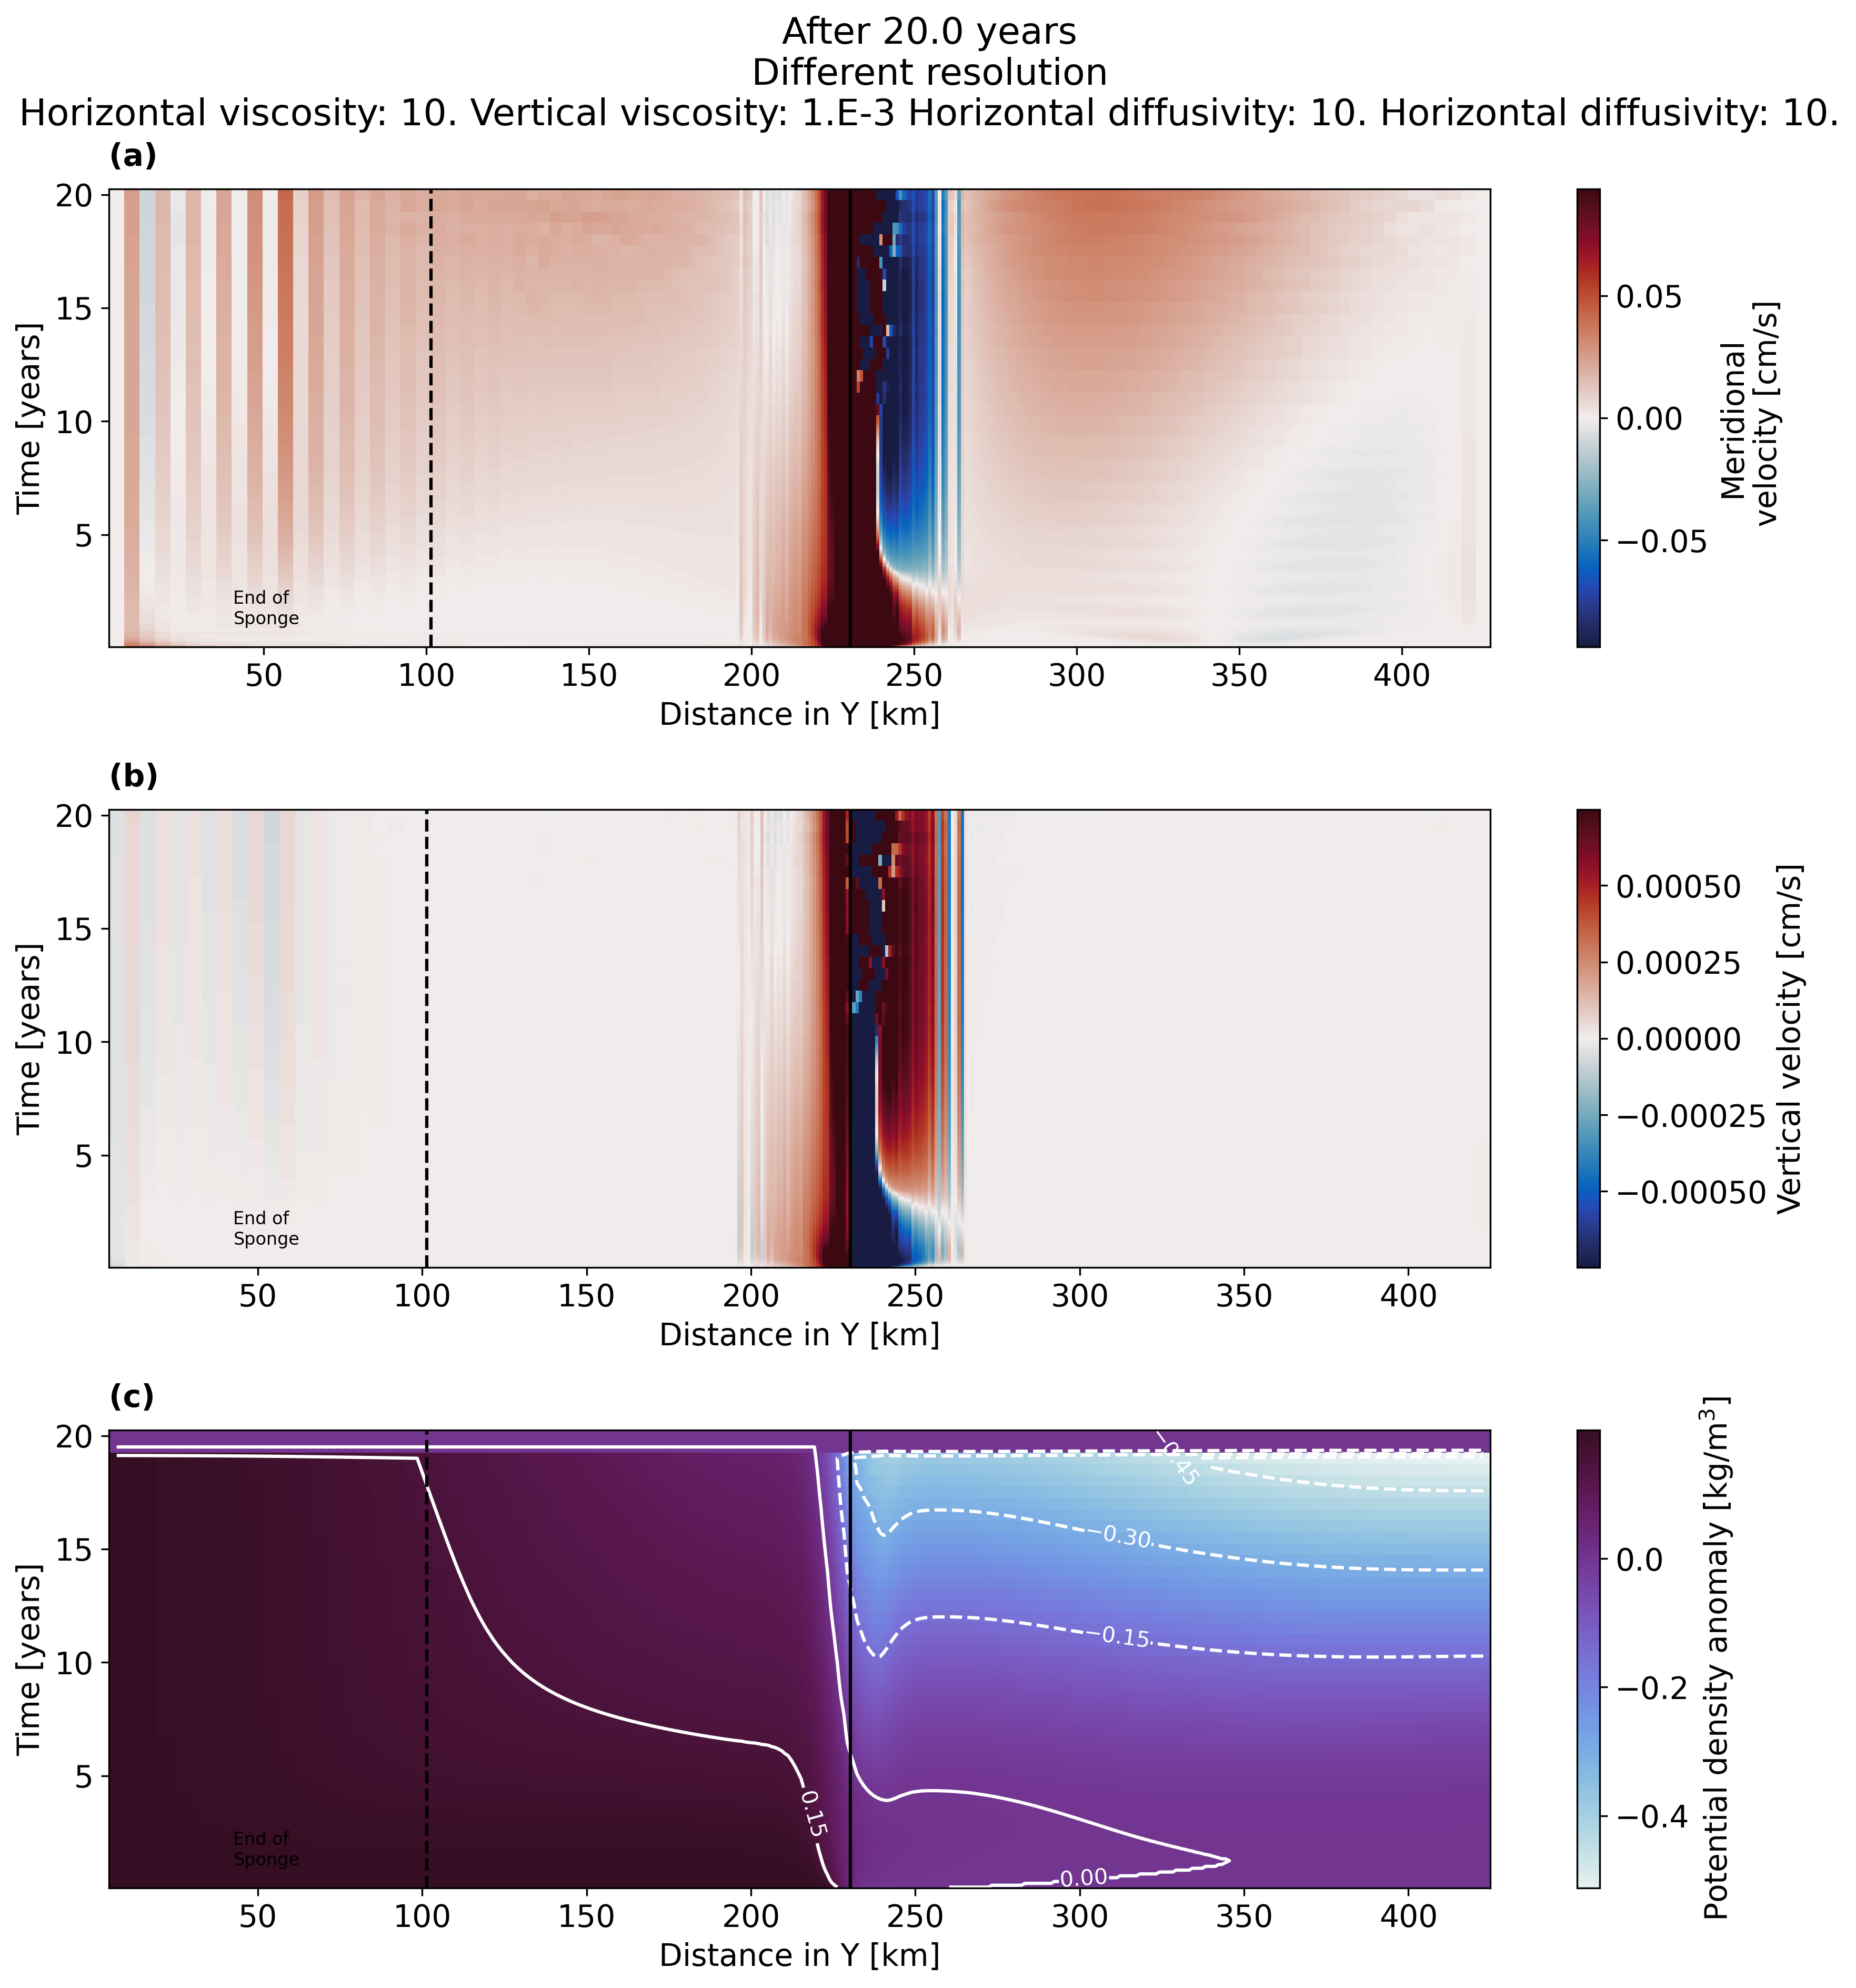

In [158]:
## Hovmöller ##

t=dsst.T[tin:]/(60*60*24*360)

fig = plt.figure()
gs = GridSpec(nrows=3, ncols=1)

axin = fig.add_subplot(gs[0, 0])

Yin=ds.Yp1[OBp:OBendp]

vmin=-np.max(velout1[tinplot:,OB:OBend]*100)/divV
vmax=np.max(velout1[tinplot:,OB:OBend]*100)/divV
cmapi=cmocean.cm.balance

levels=np.linspace(vmin,vmax,15)


cax0=axin.pcolormesh(Yin/1000, t, velout1[tin:,OBp:OBendp]*100,vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax0)
axin.set(ylabel='Time [years]',xlabel='Distance in Y [km]')
cbar_ax.set_label('Meridional\n velocity [cm/s]')

axin.axvline(ds.Y[int(umbral)]/1000,c='k')
axin.text(0, 1.05, '(a)', fontweight='bold', color='k',
        transform=axin.transAxes)
axin.axvline(ds.Y[OB]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

#axin.axhline(31,c='k',linestyle='dashed')
#axin.text(0.7, 0.35, 'Above output is averaged over 10 days\n\nBelow  output is instantaneous snapshot\nevery 10 days', color='k', 
#        transform=axin.transAxes,fontsize=8)

axin = fig.add_subplot(gs[1, 0])


Yin=ds.Y[OBp:OBendp]

vmin=np.min(Wvelout1[tinplot:,OB:OBend]*100)/divW
vmax=-np.min(Wvelout1[tinplot:,OB:OBend]*100)/divW
cmapi=cmocean.cm.balance

levels=np.linspace(vmin,vmax,15)

axin.set(ylabel='Time [years]',xlabel='Distance in Y [km]')

cax0=axin.pcolormesh(Yin/1000,t, Wvelout1[tin:,OBp:OBendp]*100,vmin=vmin,vmax=vmax,cmap=cmapi)
cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Vertical velocity [cm/s]')

axin.axvline(ds.Y[int(umbral)]/1000,c='k')
axin.text(0, 1.05, '(b)', fontweight='bold', color='k',
        transform=axin.transAxes)

axin.axvline(ds.Y[OB]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

#axin.axhline(31,c='k',linestyle='dashed')
#axin.text(0.7, 0.35, 'Above output is averaged over 10 days\n\nBelow  output is instantaneous snapshot\nevery 10 days', color='k', 
 #       transform=axin.transAxes,fontsize=8)

axin = fig.add_subplot(gs[2, 0])


Yin=ds.Y[OBp:OBendp]

vmin=np.min(Rhoout1[tinplot:,OB:OBend])
vmax=np.max(Rhoout1[tinplot:,OB:OBend])
cmapi=cmocean.cm.dense

levels=np.linspace(vmin,vmax,15)

axin.set(ylabel='Time [years]',xlabel='Distance in Y [km]')

cax0=axin.pcolormesh(Yin/1000,t, Rhoout1[tin:,OBp:OBendp],vmin=vmin,vmax=vmax,cmap=cmapi)
contours=axin.contour(Yin/1000,t, Rhoout1[tin:,OBp:OBendp],levels=5,colors='white') #np.flip([-0.9,-0.925,-0.95,-1,-1.05])
plt.clabel(contours, inline=1, fontsize=10)
cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Potential density anomaly [kg/m$^3$]')


axin.text(0, 1.05, '(c)', fontweight='bold', color='k',
        transform=axin.transAxes)

axin.axvline(ds.Y[OB]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)
axin.axvline(ds.Y[int(umbral)]/1000,c='k')
    
fig.tight_layout()
fig.suptitle(f'After {t[-1]:.1f} years\n Different resolution \n{plotNames[0]}: {plotValues[0]} {plotNames[1]}: {plotValues[1]} {plotNames[2]}: {plotValues[2]} {plotNames[2]}: {plotValues[2]}',y=1.05)


plt.savefig('../' + str(project)+'/Figures/' +str(ed)+ 'StatedifReshovmöller' +'viscHor'+str(plotValues[0])+'viscVert'+str(plotValues[1])+'diffHor'+str(plotValues[2]) +'diffVert'+str(plotValues[3])+ '.png',dpi=400)

